# <a id='toc1_'></a>[EDA — Dataset B : `Crop Yield Prediction Dataset`](#toc0_)

**Ce que fait ce notebook.** Explorer les 5 fichiers de ce jeu de données FAO, puis répondre à la question
laissée ouverte par le notebook A : *ce dataset peut-il porter le moteur de recommandation de culture ?*

Rappel du contexte. L'audit du dataset A a montré qu'il est entièrement synthétique, et que la variable
`Crop` n'a **aucun** effet sur le rendement — la recommandation y est mathématiquement impossible. Le
dataset B est donc le seul candidat restant : données réelles, 101 pays, 10 cultures, 1990-2013.

**Le fichier `yield_df.csv` est fourni prêt à l'emploi**, fusionné, sans valeur manquante. Les 4 autres
fichiers sont ses sources brutes. La première partie du notebook reconstruit cette fusion pour vérifier
comment elle a été faite — et y trouve trois pièges, dont deux qui gonflent artificiellement les
performances du modèle.

**Table of contents**<a id='toc0_'></a>    
- [EDA — Dataset B : `Crop Yield Prediction Dataset`](#toc1_)    
- [Import](#toc2_)    
- [Audit des 4 sources](#toc3_)    
  - [Piège n°1 — les fichiers n'utilisent pas la même convention de nommage](#toc3_1_)    
  - [Piège n°2 — `temp.csv` n'est pas au niveau pays](#toc3_2_)    
    - [Une limite que les données ne permettent pas de lever](#toc3_2_1_)    
  - [Piège n°3 — deux détails de format à ne pas rater](#toc3_3_)    
  - [La question des valeurs manquantes](#toc3_4_)    
    - [Ce que ces variables mesurent vraiment](#toc3_4_1_)    
  - [Laquelle de ces variables bouge vraiment ?](#toc3_5_)    
    - [Normaliser les pesticides par la surface cultivée](#toc3_5_1_)    
- [Conclusions de l'audit](#toc4_)    
  - [Ce que l'audit a trouvé](#toc4_1_)    
  - [Traitements appliqués](#toc4_2_)    
  - [Deux constats sur la structure du jeu de données](#toc4_3_)    
- [Les trois jeux de données](#toc5_)    
- [Quick Analysis](#toc6_)    
- [Target — `yield_t_per_ha`](#toc7_)    
  - [Outliers](#toc7_1_)    
- [Univariate](#toc8_)    
  - [Numerical](#toc8_1_)    
  - [Categorical](#toc8_2_)    
- [Bivariate analysis](#toc9_)    
  - [Numeric vs target](#toc9_1_)    
  - [Numeric vs categorical](#toc9_2_)    
  - [Categorical vs target — là où est le signal](#toc9_3_)    
  - [Redondance et ACP](#toc9_4_)    
- [Conclusions de l'EDA](#toc10_)    
  - [La cible](#toc10_1_)    
  - [Les variables explicatives](#toc10_2_)    
  - [L'ACP demandée par le brief](#toc10_3_)    
  - [Synthèse](#toc10_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Import](#toc0_)

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Chart style used across the notebook
BLUE = "#2b7bba"
INK = "#333333"

In [3]:
DATA_DIR = Path("..") / "data" / "Crop Yield Prediction Dataset"

# yield_df.csv - the ready-made merged file (the other four are its raw sources)
yield_df = pd.read_csv(DATA_DIR / "yield_df.csv")
print(yield_df.shape)
yield_df

(28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.00,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.00,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.00,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.00,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.00,16.37
...,...,...,...,...,...,...,...,...
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76


In [4]:
# yield.csv - FAO crop yields, hg/ha
yield_raw = pd.read_csv(DATA_DIR / "yield.csv")
print(yield_raw.shape)
yield_raw

(56717, 12)


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400
...,...,...,...,...,...,...,...,...,...,...,...,...
56712,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420
56713,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2013,2013,hg/ha,22888
56714,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2014,2014,hg/ha,21357
56715,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2015,2015,hg/ha,19826


In [5]:
# rainfall.csv - average annual rainfall per country
rainfall = pd.read_csv(DATA_DIR / "rainfall.csv")
print(rainfall.shape)
rainfall

(6727, 3)


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327
...,...,...,...
6722,Zimbabwe,2013,657
6723,Zimbabwe,2014,657
6724,Zimbabwe,2015,657
6725,Zimbabwe,2016,657


In [6]:
# pesticides.csv - pesticide use per country, tonnes
pesticides = pd.read_csv(DATA_DIR / "pesticides.csv")
print(pesticides.shape)
pesticides

(4349, 7)


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.00
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.00
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.00
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.00
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.00
...,...,...,...,...,...,...,...
4344,Pesticides Use,Zimbabwe,Use,Pesticides (total),2012,tonnes of active ingredients,3375.53
4345,Pesticides Use,Zimbabwe,Use,Pesticides (total),2013,tonnes of active ingredients,2550.07
4346,Pesticides Use,Zimbabwe,Use,Pesticides (total),2014,tonnes of active ingredients,2185.07
4347,Pesticides Use,Zimbabwe,Use,Pesticides (total),2015,tonnes of active ingredients,2185.07


In [7]:
# temp.csv - average temperature per country
temp = pd.read_csv(DATA_DIR / "temp.csv")
print(temp.shape)
temp

(71311, 3)


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN
...,...,...,...
71306,2009,Mexico,21.76
71307,2010,Mexico,20.90
71308,2011,Mexico,21.55
71309,2012,Mexico,21.52


In [8]:
# FAOSTAT Land Use (downloaded separately, see the "pesticide intensity" section below).
# The download ships 6 files: 4 are code tables, All_Data carries the source flags,
# and NOFLAG is the one to use. Wide format: one row per (country, item, element), one column per year.
# encoding="utf-8" is mandatory: in latin-1, "Türkiye" gets mangled and the country silently disappears.
DATA_LU = Path("..") / "data" / "LandUse"

land_use = pd.read_csv(DATA_LU / "Inputs_LandUse_E_All_Data_NOFLAG.csv", encoding="utf-8", low_memory=False)
print(land_use.shape)
land_use

(10296, 73)


,Area Code,Area Code (M49),Area,Item Code,Item,Element Code,Element,Unit,Y1961,Y1962,...,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023,Y2024,Y2025
0,2,'004,Afghanistan,6600,Country area,5110,Area,1000 ha,65286.00,65286.00,...,65286.00,65286.00,65286.00,65286.00,65286.00,65286.00,65286.00,65287.0000,65287.00,NaN
1,2,'004,Afghanistan,6601,Land area,5110,Area,1000 ha,65223.00,65223.00,...,65223.00,65223.00,65223.00,65223.00,65223.00,65223.00,65223.00,65223.0000,65223.00,NaN
2,2,'004,Afghanistan,6602,Agriculture,5110,Area,1000 ha,37750.00,37800.00,...,37910.00,37910.00,38010.00,38010.00,38075.00,38313.00,38313.00,38116.0000,38082.00,NaN
3,2,'004,Afghanistan,6610,Agricultural land,5110,Area,1000 ha,37750.00,37800.00,...,37910.00,37910.00,38010.00,38010.00,38075.00,38313.00,38313.00,38116.0000,38082.00,NaN
4,2,'004,Afghanistan,6610,Agricultural land,7209,Share in Land area,%,57.88,57.96,...,58.12,58.12,58.28,58.28,58.38,58.74,58.74,58.4400,58.39,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10291,5873,'198,OECD,6680,Inland waters,5110,Area,1000 ha,166398.94,166400.94,...,188001.07,188079.54,188021.33,188031.42,187672.15,204730.89,204595.32,204518.6500,204514.78,NaN
10292,5873,'198,OECD,6690,Land area equipped for irrigation,5110,Area,1000 ha,37984.00,38976.00,...,63052.39,63955.81,64812.38,64846.31,65184.20,66630.39,64743.85,64312.1036,64521.78,NaN
10293,5873,'198,OECD,6690,Land area equipped for irrigation,7252,Share in Cropland,%,9.18,9.47,...,16.21,16.46,16.76,16.85,16.92,17.30,16.88,16.8100,16.88,NaN
10294,5873,'198,OECD,6671,Agriculture area under organic agric.,5110,Area,1000 ha,NaN,NaN,...,43029.20,52290.99,52853.97,53885.57,54821.39,55469.06,56519.40,74606.2100,75903.39,NaN


# <a id='toc3_'></a>[Audit des 4 sources](#toc0_)

`yield_df.csv` est présenté comme prêt à l'emploi : 28 242 lignes, aucune valeur manquante. Avant de
l'utiliser tel quel, une question simple : **d'où viennent ces lignes, et qu'est-ce qui a été perdu en
route ?** Cette section reconstruit la fusion — et y trouve trois pièges, dont deux qui faussent
directement les performances d'un modèle.

In [9]:
# Overview of the five files: size, coverage, period
sources = {
    "yield_df.csv (merged)": (yield_df, "Area", "Year"),
    "yield.csv": (yield_raw, "Area", "Year"),
    "rainfall.csv": (rainfall, " Area", "Year"),
    "pesticides.csv": (pesticides, "Area", "Year"),
    "temp.csv": (temp, "country", "year"),
}

display(pd.DataFrame([
    {"rows": len(d), "columns": d.shape[1], "countries": d[area].nunique(),
     "from": int(d[year].min()), "to": int(d[year].max())}
    for d, area, year in sources.values()
], index=sources.keys()))

# The from/to bounds can hide holes: which years of 1990-2013 are absent from each file?
print("années absentes de la fenêtre 1990-2013 :")
for k, (d, area, year) in sources.items():
    missing = sorted(set(range(1990, 2014)) - set(d[year]))
    print(f"   {k:<22}: {missing if missing else '-'}")

,rows,columns,countries,from,to
yield_df.csv (merged),28242,8,101,1990,2013
yield.csv,56717,12,212,1961,2016
rainfall.csv,6727,3,217,1985,2017
pesticides.csv,4349,7,168,1990,2016
temp.csv,71311,3,137,1743,2013


années absentes de la fenêtre 1990-2013 :
   yield_df.csv (merged) : [2003]
   yield.csv             : -
   rainfall.csv          : [2003]
   pesticides.csv        : -
   temp.csv              : -


**Premiers écarts**

- `temp.csv` s'arrête en **2013** et `pesticides.csv` commence en **1990** → ça explique la fenêtre
  1990-2013 de `yield_df.csv`, alors que `yield.csv` couvre 1961-2016.
- Dans cette fenêtre, il manque une année : **`rainfall.csv` n'a aucune donnée pour 2003**, qui est donc
  absente de `yield_df.csv` aussi — 23 années effectives, pas 24.
- Le nombre de pays varie du simple au double selon les fichiers : 217 pour la pluie, **137 seulement pour
  la température**.
- `yield_df.csv` traîne une colonne `Unnamed: 0` — un index sauvegardé par erreur, à supprimer.

Vérifions l'hypothèse : le périmètre de `yield_df.csv` serait simplement l'**intersection** des quatre fichiers.

In [10]:
# Hypothesis: yield_df.csv keeps only what exists in all four files at once
name_col = {"yield.csv": (yield_raw, "Area"), "rainfall.csv": (rainfall, " Area"),
            "pesticides.csv": (pesticides, "Area"), "temp.csv": (temp, "country")}
country_sets = {k: set(d[c]) for k, (d, c) in name_col.items()}

overlap = set.intersection(*country_sets.values())
print(f"countries in the intersection of the 4 files : {len(overlap)}")
print(f"countries in yield_df.csv                    : {yield_df['Area'].nunique()}")
print(f"exactly the same set?                        : {overlap == set(yield_df['Area'])}")

# How many countries each file is responsible for losing
print("\nstarting from the 212 countries of yield.csv, countries lost because absent from:")
for k, s in country_sets.items():
    if k != "yield.csv":
        print(f"   {k:<16}: {len(country_sets['yield.csv'] - s):>3}")

# Afghanistan: a concrete example
print("\nAfghanistan is present in:")
for k, s in country_sets.items():
    print(f"   {k:<16}: {'yes' if 'Afghanistan' in s else 'NO'}")

countries in the intersection of the 4 files : 101
countries in yield_df.csv                    : 101
exactly the same set?                        : True

starting from the 212 countries of yield.csv, countries lost because absent from:
   rainfall.csv    :  43
   pesticides.csv  :  45
   temp.csv        :  94

Afghanistan is present in:
   yield.csv       : yes
   rainfall.csv    : yes
   pesticides.csv  : NO
   temp.csv        : yes


**Confirmé : le périmètre de `yield_df.csv` est exactement l'intersection des 4 fichiers.**

101 pays sur les 212 de `yield.csv` — on en perd **52 %**. Une jointure interne ne garde que ce qui existe
partout : il suffit qu'un seul fichier ignore un pays pour qu'il disparaisse (Afghanistan : présent dans
3 fichiers sur 4, absent de `pesticides.csv`, donc absent du résultat).

Le choix garantit zéro valeur manquante, mais il n'a jamais été documenté — et il cache un problème plus
sérieux, qu'on découvre en regardant *quels* pays sont perdus.

In [11]:
# Which countries with yield data did not make it into yield_df.csv?
items = sorted(yield_df["Item"].unique())
produced = (yield_raw[(yield_raw["Element"] == "Yield")
                      & yield_raw["Item"].isin(items)
                      & yield_raw["Year"].between(1990, 2013)]
            .groupby("Area")["Value"].agg(rows="size", mean_yield="mean"))
lost = produced[~produced.index.isin(set(yield_df["Area"]))]
print(f"{len(lost)} countries with yield data are missing from yield_df.csv")

# The three biggest losses, with their mean yield over the window
display(lost.loc[["United States of America", "China, mainland", "Russian Federation"]].round(0))

# How does each file spell the same country?
print("naming convention, file by file:")
for label, (d, c) in name_col.items():
    print(f"   {label:<16} -> {[n for n in d[c].unique() if 'United States' in str(n)]}")

111 countries with yield data are missing from yield_df.csv


,rows,mean_yield
Area,,
United States of America,168,121743.0
"China, mainland",192,88820.0
Russian Federation,132,37745.0


naming convention, file by file:
   yield.csv        -> ['United States of America']
   rainfall.csv     -> ['United States']
   pesticides.csv   -> ['United States of America']
   temp.csv         -> ['United States']


## <a id='toc3_1_'></a>[Piège n°1 — les fichiers n'utilisent pas la même convention de nommage](#toc0_)

```
yield.csv        ->  'United States of America'     (noms FAO)
pesticides.csv   ->  'United States of America'     (noms FAO)
rainfall.csv     ->  'United States'                (noms courants)
temp.csv         ->  'United States'                (noms courants)
```

Deux conventions, aucune correspondance automatique. Conséquence : **les États-Unis, la Chine et la Russie
sont absents de `yield_df.csv`** — la donnée existe, seul le nom diffère d'un fichier à l'autre. Les trois
premières puissances agricoles mondiales, perdues sur un problème d'orthographe.

Et ce n'est pas neutre : les États-Unis tournent à **121 743 hg/ha** de rendement moyen et la Chine à
**88 820**, nettement au-dessus des ~70 500 du jeu corrigé construit plus bas.

On corrigera avec une table de correspondance.

## <a id='toc3_2_'></a>[Piège n°2 — `temp.csv` n'est pas au niveau pays](#toc0_)

C'est le piège le plus coûteux, et le plus discret.

In [12]:
# Are the join keys unique in each file?
print("duplicated (country, year) keys:")
print(f"   rainfall.csv  : {rainfall.duplicated([' Area', 'Year']).sum():>6,} / {len(rainfall):,}")
print(f"   pesticides.csv: {pesticides.duplicated(['Area', 'Year']).sum():>6,} / {len(pesticides):,}")
print(f"   temp.csv      : {temp.duplicated(['country', 'year']).sum():>6,} / {len(temp):,}   <-- problem")

# What do those duplicated rows actually contain?
worst = temp.groupby(["country", "year"]).size().sort_values(ascending=False)
c, y = worst.index[0]
sample = temp[(temp["country"] == c) & (temp["year"] == y)]["avg_temp"]
print(f"\n{c}, {y}: {len(sample)} records in a single country-year")
print(f"   values from {sample.min():.2f} to {sample.max():.2f} degrees -> these are weather stations, not a country average")

# Consequence on the delivered file
print(f"\nyield_df.csv rows                    : {len(yield_df):,}")
print(f"unique (Area, Item, Year) combinations: {len(yield_df.drop_duplicates(['Area', 'Item', 'Year'])):,}")
print(f"strictly identical rows               : {yield_df.drop(columns=['Unnamed: 0']).duplicated().sum():,}")

duplicated (country, year) keys:
   rainfall.csv  :      0 / 6,727
   pesticides.csv:      0 / 4,349
   temp.csv      : 42,797 / 71,311   <-- problem

United States, 1925: 52 records in a single country-year
   values from 5.23 to 23.31 degrees -> these are weather stations, not a country average

yield_df.csv rows                    : 28,242
unique (Area, Item, Year) combinations: 13,130
strictly identical rows               : 2,310


**`temp.csv` contient plusieurs relevés par pays-année, sans aucune colonne pour les distinguer.**

États-Unis, 1925 : **52 relevés**, de 5,2 à 23,3 °C — des stations météo ou des villes, pas une moyenne
nationale. `yield_df.csv` a joint ce fichier comme si la clé `(pays, année)` était unique : chaque ligne de
rendement s'est retrouvée dupliquée autant de fois qu'il y a de relevés.

| | |
|---|---|
| Lignes dans `yield_df.csv` | **28 242** |
| Combinaisons uniques (pays, culture, année) | **13 130** |

**54 % des lignes sont des doublons**, et `avg_temp` y est la température d'une station, pas du pays. Un
pays à 22 stations pèse aussi 22 fois plus lourd qu'un pays à une seule.

In [13]:
# Inside the 1990-2013 perimeter: how heterogeneous is a country-year?
scope = temp[temp["country"].isin(set(yield_df["Area"])) & temp["year"].between(1990, 2013)]
per_key = scope.groupby(["country", "year"])["avg_temp"].agg(records="size", spread="std",
                                                             lo="min", hi="max")

print(f"country-years with a single record: {(per_key['records'] == 1).mean() * 100:.0f}%")
print(f"countries with several records    : {(per_key.groupby('country')['records'].mean() > 1).sum()} / "
      f"{per_key.index.get_level_values(0).nunique()}")

# Is the number of records stable over time? (an unstable count would create a fake trend)
counts = per_key.groupby("country")["records"].agg(["min", "max"])
print(f"countries whose record count changes over time: {(counts['min'] != counts['max']).sum()} -> no spurious trend")

print("\ncountries where a single national average hides the most:")
display(per_key.groupby("country").agg(records=("records", "mean"), avg_spread=("spread", "mean"),
                                       coldest=("lo", "mean"), hottest=("hi", "mean"))
        .dropna().sort_values("avg_spread", ascending=False).head(8).round(2))

country-years with a single record: 73%
countries with several records    : 27 / 101
countries whose record count changes over time: 0 -> no spurious trend

countries where a single national average hides the most:


,records,avg_spread,coldest,hottest
country,,,,
Chile,2.0,4.82,6.32,13.14
Brazil,11.0,3.66,18.19,27.77
Italy,2.0,3.62,7.88,12.99
Turkey,5.0,3.60,11.20,19.53
Colombia,2.0,3.45,22.50,27.38
Australia,6.0,3.04,12.12,20.15
Mexico,8.0,2.93,16.30,25.10
Spain,3.0,2.82,12.38,17.38


### <a id='toc3_2_1_'></a>[Une limite que les données ne permettent pas de lever](#toc0_)

Agréger les relevés en moyenne nationale est la seule option disponible : la cible elle-même est nationale
(la FAO publie un rendement par pays, au même niveau d'agrégation), et `temp.csv` n'a ni identifiant de
station ni coordonnées qui permettraient de pondérer par les terres cultivées. Le tableau montre ce que
cette moyenne écrase : **4,8 °C** d'écart entre stations au Chili, **3,7 °C** au Brésil.

Point rassurant : le nombre de relevés par pays est **stable sur 1990-2013** (0 pays sur 101 varie). Si le
nombre de stations avait bougé d'une année à l'autre, la « température nationale » aurait dérivé pour des
raisons purement instrumentales.

## <a id='toc3_3_'></a>[Piège n°3 — deux détails de format à ne pas rater](#toc0_)

Moins graves, mais ils font échouer silencieusement une fusion :

- `rainfall.csv` a une colonne nommée **`" Area"` avec un espace initial** → `df["Area"]` lève une `KeyError`.
- Sa colonne de pluviométrie contient des valeurs **`".."`** (donnée FAO non disponible), ce qui force le type
  en `object` : toute opération numérique échoue tant qu'on n'a pas passé `pd.to_numeric(..., errors="coerce")`.
- `temp.csv` nomme ses colonnes `year` / `country` en minuscules, là où les autres utilisent `Year` / `Area`.

## <a id='toc3_4_'></a>[La question des valeurs manquantes](#toc0_)

Puisqu'on reconstruit la fusion, faut-il vraiment se limiter à l'intersection ? Les modèles à base d'arbres
(`HistGradientBoosting`, LightGBM) gèrent nativement les `NaN` — on pourrait garder plus de pays.

La réponse dépend de **ce qui manque**.

In [14]:
# Rebuild the merge with a left join, to see what each strategy would keep
FAO_TO_COMMON = {
    "United States of America": "United States", "China, mainland": "China",
    "Russian Federation": "Russia", "Iran (Islamic Republic of)": "Iran",
    "Venezuela (Bolivarian Republic of)": "Venezuela", "Bolivia (Plurinational State of)": "Bolivia",
    "United Republic of Tanzania": "Tanzania", "Republic of Korea": "South Korea",
    "Viet Nam": "Vietnam", "Czechia": "Czech Republic",
}

# One row per (country, crop, year), FAO names normalised. yield.csv holds both "China"
# (aggregate: mainland + Hong Kong + Macao + Taiwan) and "China, mainland"; the aggregate
# must be dropped before renaming, otherwise both rows collide on the same key.
base = (yield_raw[(yield_raw["Element"] == "Yield") & yield_raw["Item"].isin(items)
                  & yield_raw["Year"].between(1990, 2013)
                  & (yield_raw["Area"] != "China")][["Area", "Item", "Year", "Value"]]
        .rename(columns={"Value": "hg/ha_yield"}))
base["Area"] = base["Area"].replace(FAO_TO_COMMON)
assert not base.duplicated(["Area", "Item", "Year"]).any(), "keys must be unique after renaming"

rain = rainfall.rename(columns={" Area": "Area"})[["Area", "Year", "average_rain_fall_mm_per_year"]].copy()
rain["average_rain_fall_mm_per_year"] = pd.to_numeric(rain["average_rain_fall_mm_per_year"], errors="coerce")
pest = pesticides[pesticides["Element"] == "Use"][["Area", "Year", "Value"]].rename(columns={"Value": "pesticides_tonnes"})
pest["Area"] = pest["Area"].replace(FAO_TO_COMMON)
temp_country = (temp.rename(columns={"country": "Area", "year": "Year"})
                .groupby(["Area", "Year"], as_index=False)["avg_temp"].mean())

merged = (base.merge(rain, on=["Area", "Year"], how="left")
              .merge(pest, on=["Area", "Year"], how="left")
              .merge(temp_country, on=["Area", "Year"], how="left"))
assert not merged.duplicated(["Area", "Item", "Year"]).any(), "the join must not duplicate rows"

B_corrected = merged.dropna()
climate_ok = merged[merged["average_rain_fall_mm_per_year"].notna() & merged["avg_temp"].notna()]

display(pd.DataFrame([
    {"rows": len(yield_df), "countries": yield_df["Area"].nunique()},
    {"rows": len(B_corrected), "countries": B_corrected["Area"].nunique()},
    {"rows": len(climate_ok), "countries": climate_ok["Area"].nunique()},
    {"rows": len(merged), "countries": merged["Area"].nunique()},
], index=["yield_df.csv as delivered (with duplicates)", "B_corrected: no NaN at all",
          "+ rows where only pesticides is missing", "+ rows where climate is missing too"]))

# Is the missingness random?
print("\nmean yield (hg/ha):")
print(f"   rows fully documented    : {B_corrected['hg/ha_yield'].mean():>8,.0f}")
print(f"   rows missing pesticides  : {merged.loc[merged['pesticides_tonnes'].isna(), 'hg/ha_yield'].mean():>8,.0f}")
print(f"   rows missing temperature : {merged.loc[merged['avg_temp'].isna(), 'hg/ha_yield'].mean():>8,.0f}")
print("\ncountries recovered by the naming table:", sorted(set(B_corrected["Area"]) - set(yield_df["Area"])))

,rows,countries
yield_df.csv as delivered (with duplicates),28242,101
B_corrected: no NaN at all,14371,109
+ rows where only pesticides is missing,15925,123
+ rows where climate is missing too,25848,211



mean yield (hg/ha):
   rows fully documented    :   70,541
   rows missing pesticides  :   57,195
   rows missing temperature :   67,799

countries recovered by the naming table: ['Bolivia', 'China', 'Czech Republic', 'Iran', 'Russia', 'Tanzania', 'United States', 'Vietnam']


**Trois périmètres possibles.**

| Périmètre | Lignes | Pays |
|---|---|---|
| `yield_df.csv` livré (doublons inclus) | 28 242 | 101 |
| **Strict, sans aucun NaN, noms corrigés** | **14 371** | **109** |
| + lignes où seul `pesticides` manque | 15 925 | 123 |
| + lignes où le climat manque aussi | 25 848 | 211 |

**La table de correspondance récupère 8 pays**, dont les États-Unis, la Chine et la Russie — gratuit, à
faire dans tous les cas. Au passage, `yield.csv` contient à la fois `China` (agrégat incluant Hong Kong,
Macao et Taïwan) et `China, mainland` : l'agrégat doit être écarté avant le renommage, sous peine de deux
lignes pour la même clé — d'où le premier `assert`.

**Pour les valeurs manquantes, le critère est la nature du manque.** Les trous ne sont pas aléatoires :
rendement moyen de **70 541** hg/ha sur les lignes complètes, **57 195** là où les pesticides manquent
(−19 %), 67 799 là où la température manque (−4 %). Les pays mal documentés par la FAO sont aussi les pays
à faible rendement : garder ces lignes (les arbres gèrent les `NaN`) apprendrait au modèle « donnée
absente = rendement bas ».

> **Décision retenue : périmètre strict, noms corrigés — 14 371 lignes, 109 pays, aucun `NaN`.**

Reste une question que ce tableau ne pose pas : ces trois variables mesurent-elles vraiment « les
conditions d'une parcelle » ?

In [15]:
# What do the three "plot conditions" of the brief actually measure?
print("pesticides.csv, as declared by FAO:")
for col in ["Domain", "Element", "Item", "Unit"]:
    print(f"   {col:<8}: {pesticides[col].unique()[0]}")

print("\nannual pesticide use, a few countries (tonnes of active ingredients):")
display(yield_df[yield_df["Area"].isin(["Belgium", "France", "India"])]
        .groupby("Area")["pesticides_tonnes"].agg(["min", "max"]).round(0))

# Does rainfall carry any yearly information, or is it a constant per country?
per_country = rainfall.rename(columns={" Area": "Area"}).groupby("Area")["average_rain_fall_mm_per_year"].nunique()
print(f"countries with ONE single rainfall value across all years: {(per_country == 1).sum()} / {len(per_country)}")

pesticides.csv, as declared by FAO:
   Domain  : Pesticides Use
   Element : Use
   Item    : Pesticides (total)
   Unit    : tonnes of active ingredients

annual pesticide use, a few countries (tonnes of active ingredients):


,min,max
Area,,
Belgium,4645.0,9776.0
France,61039.0,114695.0
India,14485.0,75000.0


countries with ONE single rainfall value across all years: 188 / 217


### <a id='toc3_4_1_'></a>[Ce que ces variables mesurent vraiment](#toc0_)

| Colonne | Ce que le brief laisse croire | Ce que c'est réellement |
|---|---|---|
| `pesticides_tonnes` | ce que l'agriculteur épand sur sa parcelle | **la consommation annuelle du pays entier**, en tonnes de matière active |
| `average_rain_fall_mm_per_year` | la pluviométrie de sa parcelle | une **normale climatique nationale** — constante dans le temps pour **188 pays sur 217** |
| `avg_temp` | la température de sa parcelle | la moyenne des relevés de stations du pays (voir ci-dessus) |

**Aucune des trois n'est une donnée de parcelle — ce sont trois agrégats nationaux.** Et une pluviométrie
constante par pays ne décrit pas un climat annuel : elle caractérise un pays. On y reviendra dans
l'analyse bivariée.

## <a id='toc3_5_'></a>[Laquelle de ces variables bouge vraiment ?](#toc0_)

Une variable qui ne varie pas dans le temps ne peut expliquer aucune variation temporelle du rendement —
elle ne sert qu'à distinguer les pays entre eux. Mesurons donc la part de chaque variable imputable au pays.

In [16]:
def sums_of_squares(values, groups):
    """SCT = SCE + SCR decomposition for a categorical factor.

    SCT: total sum of squares      -- all the variation of the variable
    SCE: explained sum of squares  -- between-group variation
    SCR: residual sum of squares   -- variation left inside the groups
    """
    grand_mean = values.mean()
    group_mean = values.groupby(groups).transform("mean")
    sct = ((values - grand_mean) ** 2).sum()
    sce = ((group_mean - grand_mean) ** 2).sum()
    scr = ((values - group_mean) ** 2).sum()
    return sct, sce, scr


# The identity, illustrated on the target with country as the factor
sct, sce, scr = sums_of_squares(B_corrected["hg/ha_yield"], B_corrected["Area"])
print(f"SCT = {sct:,.0f}")
print(f"SCE = {sce:,.0f}   (entre pays)")
print(f"SCR = {scr:,.0f}   (dans les pays)")
print(f"SCE + SCR = {sce + scr:,.0f}   -> identité exacte : {abs(sct - sce - scr) / sct < 1e-9}")

# eta² = SCE/SCT: share of a variable's variation attributable to the country.
# 100% would mean the variable is nothing but a country label.
rows = {}
for col in ["average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes", "hg/ha_yield"]:
    sct, sce, scr = sums_of_squares(B_corrected[col], B_corrected["Area"])
    rows[col] = {"SCE / SCT (%)": sce / sct * 100}
display(pd.DataFrame(rows).T.round(1))

# Does the value move at all inside a country over 1990-2013?
print("comportement à l'intérieur d'un pays :")
for col in ["average_rain_fall_mm_per_year", "avg_temp", "pesticides_tonnes"]:
    n_unique = B_corrected.groupby("Area")[col].nunique()
    spread = B_corrected.groupby("Area")[col].std().median()
    print(f"   {col:<32} constante pour {(n_unique == 1).sum():>3}/{len(n_unique)} pays"
          f"   |   écart-type intra-pays médian = {spread:.2f}")

SCT = 89,029,018,125,087
SCE = 18,317,360,010,725   (entre pays)
SCR = 70,711,658,114,362   (dans les pays)
SCE + SCR = 89,029,018,125,087   -> identité exacte : True


,SCE / SCT (%)
average_rain_fall_mm_per_year,100.0
avg_temp,99.6
pesticides_tonnes,93.4
hg/ha_yield,20.6


comportement à l'intérieur d'un pays :
   average_rain_fall_mm_per_year    constante pour 109/109 pays   |   écart-type intra-pays médian = 0.00
   avg_temp                         constante pour   0/109 pays   |   écart-type intra-pays médian = 0.43
   pesticides_tonnes                constante pour   2/109 pays   |   écart-type intra-pays médian = 676.35


**Le résultat est net.**

La décomposition **SCT = SCE + SCR** partage la variation totale d'une variable entre ce qui sépare les
pays (SCE) et ce qui subsiste à l'intérieur de chacun (SCR) ; le rapport **η² = SCE / SCT** donne la part
imputable au pays.

| Variable | η² pays | Part intra-pays (1 − η²) |
|---|---|---|
| `average_rain_fall_mm_per_year` | **100,0 %** | **0 %** — constante pour les 109 pays |
| `avg_temp` | 99,6 % | 0,4 % (écart-type intra-pays médian : 0,4 °C) |
| `pesticides_tonnes` | 93,4 % | 6,6 % — la seule à vraiment bouger dans le temps |
| **`hg/ha_yield`** (la cible) | **20,6 %** | **79,4 %** |

Deux lectures à faire ensemble :

1. **À η² = 100 %, la pluviométrie est mathématiquement indiscernable d'un identifiant de pays** :
   connaître le pays suffit à connaître la valeur, exactement.
2. **La cible, elle, ne doit que 20,6 % de sa variation au pays** : les 79,4 % restants se jouent à
   l'intérieur des pays, d'une culture et d'une année à l'autre. Les variables explicatives vivent sur une
   dimension où la cible ne bouge presque pas.

Seule `pesticides_tonnes` porte une dynamique temporelle — mais en l'état elle mélange taille du pays et
intensité des pratiques.

### <a id='toc3_5_1_'></a>[Normaliser les pesticides par la surface cultivée](#toc0_)

`pesticides_tonnes` mélange deux choses : la **taille du pays** et l'**intensité des pratiques**. La France
« consomme » 84 000 t/an contre 46 000 t/an pour l'Inde — sans rapporter à la surface, la comparaison n'a
aucun sens agronomique.

On introduit donc une **troisième source** : le domaine *Land Use* de FAOSTAT, qui publie la surface
`Cropland` (terres arables + cultures permanentes) par pays et par année.

**Pourquoi `Cropland` et pas `Agricultural land`** : la seconde inclut les prairies et pâturages permanents,
où l'on n'épand pas de pesticides. L'utiliser écraserait artificiellement les pays à élevage extensif
(Australie, Argentine).

In [17]:
# Land Use is wide (one column per year): keep Cropland areas and reshape to one row per (country, year).
LU_EXTRA = {
    "Netherlands (Kingdom of the)": "Netherlands",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Türkiye": "Turkey",
}

cropland = land_use[(land_use["Item"] == "Cropland") & (land_use["Element"] == "Area")].copy()

# "China" is an aggregate (mainland + Hong Kong + Macao + Taiwan). Our naming table maps
# "China, mainland" to "China", so keeping both would create two rows for the same key.
cropland = cropland[cropland["Area"] != "China"]
cropland["Area"] = cropland["Area"].replace(FAO_TO_COMMON | LU_EXTRA)

year_cols = [f"Y{y}" for y in range(1990, 2014)]
cropland = (cropland.melt(id_vars=["Area"], value_vars=year_cols,
                          var_name="Year", value_name="cropland_1000ha")
            .dropna(subset=["cropland_1000ha"]))
cropland["Year"] = cropland["Year"].str[1:].astype(int)
assert not cropland.duplicated(["Area", "Year"]).any(), "one row per (country, year) is required"

# Pesticide intensity: tonnes of active ingredient -> kg per hectare of cropland
B_enriched = B_corrected.merge(cropland, on=["Area", "Year"], how="left")
B_enriched["pesticides_kg_per_ha"] = B_enriched["pesticides_tonnes"] * 1_000 / (B_enriched["cropland_1000ha"] * 1_000)

print(f"rows before join: {len(B_corrected):,}   after: {len(B_enriched):,}   (must be equal)")
print(f"coverage: {B_enriched['cropland_1000ha'].notna().mean() * 100:.1f}% of rows")
print(f"countries without a cropland area: {sorted(set(B_enriched.loc[B_enriched['cropland_1000ha'].isna(), 'Area']))}")

print("\nraw tonnage vs intensity:")
display(B_enriched[B_enriched["Area"].isin(["India", "Australia", "United States", "Brazil", "France", "Belgium"])]
        .groupby("Area")[["pesticides_tonnes", "cropland_1000ha", "pesticides_kg_per_ha"]]
        .median().round(2).sort_values("pesticides_kg_per_ha"))

print("distribution of the intensity (kg/ha):")
print(B_enriched["pesticides_kg_per_ha"].describe(percentiles=[0.05, 0.5, 0.95]).round(3).to_string())

# Cleaning decision: convert the target to t/ha, the unit used in dataset A and in the business report.
# FAO publishes yields in hectograms per hectare; 1 t/ha = 10 000 hg/ha.
B_enriched["yield_t_per_ha"] = B_enriched["hg/ha_yield"] / 10_000
print(f"\ntarget converted: median {B_enriched['yield_t_per_ha'].median():.2f} t/ha "
      f"(range {B_enriched['yield_t_per_ha'].min():.2f} to {B_enriched['yield_t_per_ha'].max():.2f})")

rows before join: 14,371   after: 14,371   (must be equal)
coverage: 100.0% of rows
countries without a cropland area: []

raw tonnage vs intensity:


,pesticides_tonnes,cropland_1000ha,pesticides_kg_per_ha
Area,,,
India,46195.00,169891.0,0.27
Australia,34091.00,23769.0,1.41
United States,407779.20,178068.0,2.36
Brazil,145552.00,56456.0,2.56
France,84011.00,19347.8,4.34
Belgium,6712.05,861.3,7.81


distribution of the intensity (kg/ha):
count    14371.000
mean         2.456
std          4.617
min          0.000
5%           0.006
50%          0.924
95%          8.877
max         60.574

target converted: median 3.99 t/ha (range 0.01 to 50.14)


**La variable a récupéré un sens.**

| Pays | Tonnage brut | Cropland (1000 ha) | **kg/ha** |
|---|---|---|---|
| Inde | 46 195 | 169 891 | **0,27** |
| Australie | 34 091 | 23 769 | **1,41** |
| États-Unis | 407 779 | 178 068 | **2,36** |
| Brésil | 145 552 | 56 456 | **2,56** |
| France | 84 011 | 19 348 | **4,34** |
| Belgique | 6 712 | 861 | **7,81** |

Le classement brut était un classement de **tailles de pays** ; le classement normalisé — Benelux intensif
en tête, Inde et Australie extensives en queue — est celui qu'un agronome attend.

**Trois pièges à l'intégration**, du même genre que ceux de l'audit :

1. **Encodage** : le fichier est en UTF-8. Lu en latin-1, `Türkiye` est mangé et la Turquie disparaît sans
   aucune erreur.
2. **Trois noms de plus à mapper** : `Netherlands (Kingdom of the)`, `United Kingdom of...`, `Türkiye`.
3. **La même collision `China` / `China, mainland` que dans `yield.csv`** — d'où l'exclusion de l'agrégat
   et l'`assert` dans la cellule.

**Un point à traiter à l'univarié** : l'intensité a une queue très longue (médiane ~0,9 kg/ha, max ~60),
venant de micro-territoires où le tonnage déclaré inclut probablement des usages non agricoles. À arbitrer
plus tard : passage au log, ou exclusion des micro-surfaces.

In [18]:
# Same eta² decomposition as above, now for the pesticide variable before and after
# normalisation by cropland area. Same rows/countries used for both columns, so the
# comparison isolates the effect of the normalisation itself.
pest_complete = B_enriched.dropna(subset=["pesticides_kg_per_ha"])

rows = {}
for col in ["pesticides_tonnes", "pesticides_kg_per_ha"]:
    sct, sce, scr = sums_of_squares(pest_complete[col], pest_complete["Area"])
    rows[col] = {"SCE / SCT (%)": sce / sct * 100}
display(pd.DataFrame(rows).T.round(1))

print("comportement à l'intérieur d'un pays :")
for col in ["pesticides_tonnes", "pesticides_kg_per_ha"]:
    n_unique = pest_complete.groupby("Area")[col].nunique()
    spread = pest_complete.groupby("Area")[col].std().median()
    print(f"   {col:<24} constante pour {(n_unique == 1).sum():>3}/{len(n_unique)} pays"
          f"   |   écart-type intra-pays médian = {spread:.3f}")

,SCE / SCT (%)
pesticides_tonnes,93.4
pesticides_kg_per_ha,79.2


comportement à l'intérieur d'un pays :
   pesticides_tonnes        constante pour   2/109 pays   |   écart-type intra-pays médian = 676.349
   pesticides_kg_per_ha     constante pour   0/109 pays   |   écart-type intra-pays médian = 0.394


# <a id='toc4_'></a>[Conclusions de l'audit](#toc0_)

## <a id='toc4_1_'></a>[Ce que l'audit a trouvé](#toc0_)

| # | Constat | Mesure |
|---|---|---|
| 1 | `yield_df.csv` est l'**intersection non documentée** des 4 fichiers | 101 pays sur 212 |
| 2 | **Deux conventions de nommage** (FAO vs courant) selon les fichiers | **USA, Chine et Russie absents** du fichier livré |
| 3 | **`temp.csv` est au niveau station**, pas pays | **54 % de doublons** dans le fichier livré |
| 4 | Détails de format : `" Area"` avec espace, valeurs `".."`, minuscules, encodage, agrégat `China` | échecs de fusion silencieux |
| 5 | Les 3 variables d'entrée sont des **agrégats nationaux**, pas des mesures de parcelle | la pluviométrie est même constante par pays |
| 6 | **2003 est absente** de `rainfall.csv` | 23 années effectives, pas 24 |

## <a id='toc4_2_'></a>[Traitements appliqués](#toc0_)

1. **Agrégation de `temp.csv`** par (pays, année) avant toute jointure — une clé, une ligne.
2. **Normalisation des noms de pays** par table FAO → courant, agrégat `China` écarté.
3. **Conversion de la pluviométrie** en numérique (`errors="coerce"`), renommage de `" Area"`.
4. **Jointure interne stricte** sur (pays, année) → 14 371 lignes, 109 pays, aucun `NaN`.
5. **Suppression** de `Unnamed: 0` ; **conversion** `hg/ha` → `t/ha` (`yield_t_per_ha`, ÷ 10 000).
6. **Normalisation des pesticides** par la surface `Cropland` → `pesticides_kg_per_ha`. C'est une source
   externe ajoutée au brief (FAOSTAT *Land Use*) : un tonnage national ne se compare pas d'un pays à
   l'autre, une intensité en kg/ha si.

## <a id='toc4_3_'></a>[Deux constats sur la structure du jeu de données](#toc0_)

Avant de clore l'audit, deux propriétés qui caractérisent ce jeu de données.

In [19]:
# (1) Ranking crops by tonnage: is the winner always the same?
print("rendement médian par culture (t/ha) :")
print(B_enriched.groupby("Item")["yield_t_per_ha"].median().round(2)
      .sort_values(ascending=False).to_string())

# (2) Is every crop actually observed in every climate?
all_crops = set(B_enriched["Item"])


def observed(df, label):
    seen = set(df.groupby("Item").size()[lambda s: s >= 10].index)
    print(f"   {label:<34} {len(seen)}/10   absentes : {sorted(all_crops - seen)}")


print("\ncultures réellement observées :")
observed(B_enriched[(B_enriched["avg_temp"] - 10).abs() <= 2], "autour de 10 °C")
observed(B_enriched[((B_enriched["avg_temp"] - 10).abs() <= 2)
                    & B_enriched["average_rain_fall_mm_per_year"].between(600, 1000)],
         "10 °C + 600-1000 mm de pluie")

rendement médian par culture (t/ha) :
Item
Potatoes                16.00
Cassava                 10.00
Plantains and others     9.53
Yams                     9.15
Sweet potatoes           8.65
Rice, paddy              3.47
Maize                    2.52
Wheat                    2.41
Soybeans                 1.62
Sorghum                  1.26

cultures réellement observées :
   autour de 10 °C                    9/10   absentes : ['Yams']
   10 °C + 600-1000 mm de pluie       7/10   absentes : ['Cassava', 'Plantains and others', 'Yams']


**1. Les niveaux de rendement sont très inégaux entre cultures.** 16 t/ha médians pour Potatoes,
1,26 pour Sorghum — un facteur 12, et les cinq tubercules occupent les cinq premières places. Toute
comparaison entre cultures en tonnage brut est dominée par cette hiérarchie de densité de matière.

**2. Toutes les cultures ne sont pas documentées partout.** Autour de 10 °C, Yams n'a aucune
observation ; en ajoutant une contrainte de pluie (600-1000 mm), il ne reste que **7 cultures sur 10**.
L'espace (culture × climat) n'est pas couvert uniformément : certaines combinaisons n'existent tout
simplement pas dans les données.

# <a id='toc5_'></a>[Les trois jeux de données](#toc0_)

L'audit est terminé. On en sort avec **trois versions du dataset**, gardées côte à côte : la suite de
l'analyse se fait sur la dernière, mais les deux autres restent disponibles pour comparer les résultats.

| Nom | Ce que c'est | À quoi ça sert |
|---|---|---|
| `B_original` | `yield_df.csv` tel que livré | référence de comparaison — et démonstration de ce que coûtent ses doublons |
| `B_corrected` | noms normalisés, `temp` moyennée par pays, jointure interne stricte | le jeu propre, sans source externe. Utile pour isoler l'effet de nos corrections |
| `B_enriched` | `B_corrected` + surface cultivée → intensité en kg/ha | **le jeu de travail** pour la suite |

In [20]:
# The three versions, kept side by side. B_corrected and B_enriched were built above.
B_original = yield_df   # exactly as delivered, nothing removed - it is the comparison baseline

summary = pd.DataFrame([
    {"lignes": len(d), "pays": d["Area"].nunique(),
     "combinaisons uniques (Area, Item, Year)": len(d.drop_duplicates(["Area", "Item", "Year"])),
     "colonnes": d.shape[1]}
    for d in (B_original, B_corrected, B_enriched)
], index=["B_original  (livré)", "B_corrected (nos corrections)", "B_enriched  (+ land use)"])
display(summary)

print("colonnes de B_enriched :", list(B_enriched.columns))
print("\nLa suite de l'analyse utilise B_enriched.")
B_enriched

,lignes,pays,"combinaisons uniques (Area, Item, Year)",colonnes
B_original (livré),28242,101,13130,8
B_corrected (nos corrections),14371,109,14371,7
B_enriched (+ land use),14371,109,14371,10


colonnes de B_enriched : ['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'cropland_1000ha', 'pesticides_kg_per_ha', 'yield_t_per_ha']

La suite de l'analyse utilise B_enriched.


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,cropland_1000ha,pesticides_kg_per_ha,yield_t_per_ha
0,Albania,Maize,1990,36613,1485.0,121.00,16.37,704.00,0.171875,3.6613
1,Albania,Maize,1991,29068,1485.0,121.00,15.36,703.00,0.172119,2.9068
2,Albania,Maize,1992,24876,1485.0,121.00,16.06,703.00,0.172119,2.4876
3,Albania,Maize,1993,24185,1485.0,121.00,16.05,702.00,0.172365,2.4185
4,Albania,Maize,1994,25848,1485.0,201.00,16.96,702.00,0.286325,2.5848
...,...,...,...,...,...,...,...,...,...,...
14366,Zimbabwe,Wheat,2009,30000,657.0,3269.99,20.52,4138.32,0.790173,3.0000
14367,Zimbabwe,Wheat,2010,27681,657.0,3305.17,21.17,4036.77,0.818766,2.7681
14368,Zimbabwe,Wheat,2011,26274,657.0,3340.35,20.78,4237.18,0.788343,2.6274
14369,Zimbabwe,Wheat,2012,24420,657.0,3375.53,20.52,4090.14,0.825285,2.4420


**Lecture du tableau.**

`B_original` annonce 28 242 lignes pour seulement 13 130 combinaisons uniques ; `B_corrected` en compte
14 371, une par (pays, culture, année) — moins de lignes que l'original mais **plus d'information**
(109 pays, dont USA, Chine et Russie). `B_enriched` ajoute ses deux colonnes sans perdre une ligne.

**Unité de la cible** : la FAO publie en hectogrammes par hectare ; **`yield_t_per_ha`** (÷ 10 000) est
l'unité de travail pour la suite — celle du dataset A et du rapport métier. `hg/ha_yield` est conservée
pour comparaison aux fichiers sources.

# <a id='toc6_'></a>[Quick Analysis](#toc0_)

In [21]:
B_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14371 entries, 0 to 14370
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           14371 non-null  object 
 1   Item                           14371 non-null  object 
 2   Year                           14371 non-null  int64  
 3   hg/ha_yield                    14371 non-null  int64  
 4   average_rain_fall_mm_per_year  14371 non-null  float64
 5   pesticides_tonnes              14371 non-null  float64
 6   avg_temp                       14371 non-null  float64
 7   cropland_1000ha                14371 non-null  float64
 8   pesticides_kg_per_ha           14371 non-null  float64
 9   yield_t_per_ha                 14371 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 1.1+ MB


In [22]:
B_enriched.describe().round(2)

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,cropland_1000ha,pesticides_kg_per_ha,yield_t_per_ha
count,14371.00,14371.00,14371.00,14371.00,14371.00,14371.00,14371.00,14371.00
mean,2001.62,70541.14,1134.34,35759.84,19.47,14395.82,2.46,7.05
std,7.03,78711.36,725.99,160847.42,6.83,32141.09,4.62,7.87
min,1990.00,50.00,51.00,0.04,1.30,4.53,0.00,0.00
25%,1995.00,18140.00,608.00,289.90,14.85,1534.00,0.12,1.81
50%,2001.00,39897.00,1032.00,2853.74,20.40,3736.64,0.92,3.99
75%,2008.00,95761.00,1604.00,15453.46,25.72,10001.31,2.89,9.58
max,2013.00,501412.00,3240.00,1806000.00,30.42,187776.00,60.57,50.14


In [23]:
# Non-numeric columns: how many distinct values, and which ones
for col in B_enriched.select_dtypes(exclude=np.number).columns:
    values = B_enriched[col].unique().tolist()
    preview = sorted(values) if len(values) <= 12 else sorted(values)[:6] + ["..."]
    print(f"{col} — {len(values)} distinct: {preview}")

Area — 109 distinct: ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', '...']
Item — 10 distinct: ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']


In [24]:
# Working columns. Two are set aside on purpose:
#   hg/ha_yield        -> same information as the target, in another unit
#   pesticides_tonnes  -> superseded by pesticides_kg_per_ha (a national total, not an intensity)
target = B_enriched["yield_t_per_ha"]
colnum = B_enriched.select_dtypes(include=np.number).columns.drop(
    ["yield_t_per_ha", "hg/ha_yield", "pesticides_tonnes"])
colcat = B_enriched.select_dtypes(exclude=np.number).columns

print("numériques :", list(colnum))
print("catégorielles :", list(colcat))

numériques : ['Year', 'average_rain_fall_mm_per_year', 'avg_temp', 'cropland_1000ha', 'pesticides_kg_per_ha']
catégorielles : ['Area', 'Item']


**Premiers constats**

- 14 371 lignes × 10 colonnes, **aucune valeur manquante** — résultat de l'audit, pas propriété du fichier
  d'origine.
- Granularité **pays × culture × année** : `Area` (109 pays) × `Item` (10 cultures) × 23 années
  (1990-2013, sans 2003).
- 5 variables explicatives numériques, 2 catégorielles, 1 cible.
- `Area` compte 109 modalités : inutilisable en `countplot`, elle sera traitée autrement.

# <a id='toc7_'></a>[Target — `yield_t_per_ha`](#toc0_)

,yield_t_per_ha
count,14371.000
missing,0.000
mean,7.054
std,7.871
CV (std / mean),1.116
min,0.005
5%,0.700
Q1 (25%),1.814
median,3.990
Q3 (75%),9.576


C:\Users\Kevin\AppData\Local\Temp\ipykernel_10916\1265800779.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


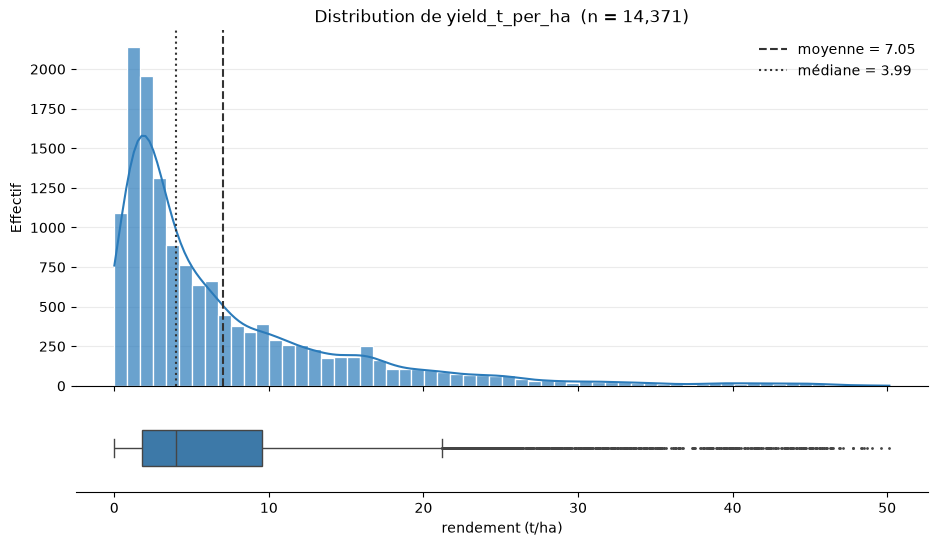

In [25]:
q1, q3 = target.quantile([0.25, 0.75])
iqr = q3 - q1
low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

stats = pd.Series({
    "count": target.size,
    "missing": target.isna().sum(),
    "mean": target.mean(),
    "std": target.std(),
    "CV (std / mean)": target.std() / target.mean(),
    "min": target.min(),
    "5%": target.quantile(0.05),
    "Q1 (25%)": q1,
    "median": target.median(),
    "Q3 (75%)": q3,
    "95%": target.quantile(0.95),
    "max": target.max(),
    "IQR": iqr,
    "skewness": target.skew(),
    "kurtosis (excess)": target.kurtosis(),
    "outliers (1.5 x IQR)": ((target < low_fence) | (target > high_fence)).sum(),
})
display(stats.to_frame(target.name).round(3))

fig, (ax_hist, ax_box) = plt.subplots(
    2, 1, sharex=True, figsize=(11, 6),
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.08},
)
sns.histplot(target, bins=60, color=BLUE, alpha=0.7, edgecolor="white", kde=True, ax=ax_hist)
ax_hist.axvline(target.mean(), color=INK, ls="--", lw=1.5, label=f"moyenne = {target.mean():.2f}")
ax_hist.axvline(target.median(), color=INK, ls=":", lw=1.5, label=f"médiane = {target.median():.2f}")
ax_hist.legend(frameon=False)
ax_hist.set_title(f"Distribution de {target.name}  (n = {target.size:,})")
ax_hist.set_xlabel("")
ax_hist.set_ylabel("Effectif")
ax_hist.grid(axis="y", alpha=0.25)
ax_hist.set_axisbelow(True)

sns.boxplot(x=target, color=BLUE, width=0.4, fliersize=1, ax=ax_box)
ax_box.set_xlabel("rendement (t/ha)")
ax_box.set_yticks([])

sns.despine(fig=fig, left=True)
fig.tight_layout()
plt.show()

**Lecture de la distribution — l'opposé exact du dataset A.**

- Moyenne **7,05** contre médiane **3,99** ; skewness **2,11**, kurtosis excédentaire **5,20** →
  distribution fortement **asymétrique à droite**, à queue épaisse (dataset A : skewness 0,000, queues fines).
- Étendue : de **0,005** à **50,1 t/ha**.

Cette forme n'a rien d'anormal : la cible **mélange 10 cultures** dont les niveaux n'ont rien à voir. Un
histogramme global de rendements toutes cultures confondues a peu de sens agronomique — c'est déjà une
information en soi.

## <a id='toc7_1_'></a>[Outliers](#toc0_)

In [26]:
z = (target - target.mean()) / target.std()
flags = pd.DataFrame({
    "1.5 x IQR": (target < low_fence) | (target > high_fence),
    "3.0 x IQR": (target < q1 - 3 * iqr) | (target > q3 + 3 * iqr),
    "|z| > 3": z.abs() > 3,
})
display(pd.DataFrame({"n": flags.sum(), "% des lignes": (flags.mean() * 100).round(2)}))

# Which crops do those "outliers" belong to?
outliers = (target < low_fence) | (target > high_fence)
print("répartition des outliers 1.5 x IQR par culture :")
print(B_enriched.loc[outliers, "Item"].value_counts().to_string())

# Same rule, but applied inside each crop instead of on the pooled target
def flag_within(s):
    a, b = s.quantile(0.25), s.quantile(0.75)
    return (s < a - 1.5 * (b - a)) | (s > b + 1.5 * (b - a))

within = B_enriched.groupby("Item")["yield_t_per_ha"].transform(flag_within)
print(f"\noutliers sur la cible globale : {outliers.sum():>4} ({outliers.mean() * 100:.2f} %)")
print(f"outliers culture par culture  : {within.sum():>4} ({within.mean() * 100:.2f} %)")

,n,% des lignes
1.5 x IQR,917,6.38
3.0 x IQR,264,1.84
|z| > 3,331,2.30


répartition des outliers 1.5 x IQR par culture :
Item
Potatoes                693
Sweet potatoes          117
Cassava                  49
Plantains and others     42
Yams                     16

outliers sur la cible globale :  917 (6.38 %)
outliers culture par culture  :  370 (2.57 %)


**Les « outliers » ne sont pas des anomalies, ce sont des tubercules.**

La règle 1,5 × IQR signale 917 lignes (6,4 %) : 693 Potatoes, 117 Sweet potatoes, 49 Cassava, 42 Plantains,
16 Yams — **pas une seule céréale**. Ce ne sont pas des erreurs de mesure : ce sont les rendements normaux
des cultures à fort tonnage, signalés parce qu'ils sortent de la masse des céréales. La preuve : appliquée
**à l'intérieur de chaque culture**, la même règle n'en signale plus que 370 (2,6 %) — près de 60 % de moins.

> **Aucune suppression.** Observations légitimes, révélées par un mélange de populations. Corollaire :
> toute analyse de la cible doit être conduite **par culture**, jamais globalement.

cible brute : skewness   2.11 | kurtosis   5.20
log10(cible): skewness  -0.20 | kurtosis   0.01
log10 par culture : skewness de -2.91 (Soybeans) à -0.06, médiane -0.43


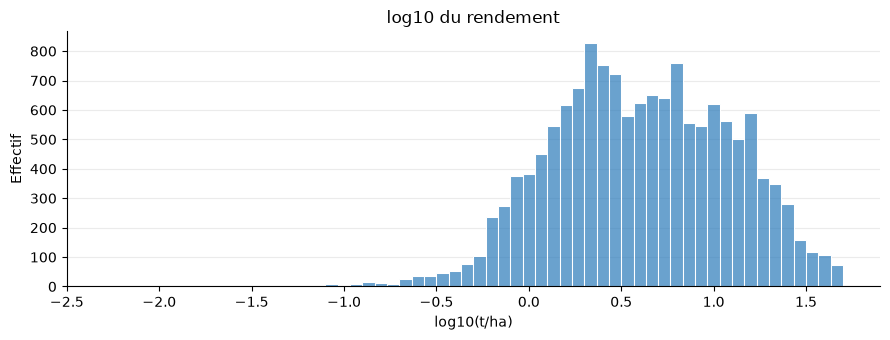

In [27]:
# Is the skew just a mixture effect, or is the target itself log-shaped?
log_target = np.log10(target)
print(f"cible brute : skewness {target.skew():>6.2f} | kurtosis {target.kurtosis():>6.2f}")
print(f"log10(cible): skewness {log_target.skew():>6.2f} | kurtosis {log_target.kurtosis():>6.2f}")

# Same check inside each crop, to separate the two effects
per_crop = B_enriched.groupby("Item")["yield_t_per_ha"].apply(lambda s: np.log10(s).skew())
print(f"log10 par culture : skewness de {per_crop.min():.2f} ({per_crop.idxmin()}) "
      f"à {per_crop.max():.2f}, médiane {per_crop.median():.2f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(log_target, bins=60, color=BLUE, alpha=0.7, edgecolor="white", ax=ax)
ax.set_title("log10 du rendement")
ax.set_xlabel("log10(t/ha)")
ax.set_ylabel("Effectif")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**En log, la cible poolée devient quasi symétrique : skewness −0,20, kurtosis 0,01.**

Les écarts de rendement sont multiplicatifs plutôt qu'additifs — on parle de « +20 % de rendement », pas de
« +2 t/ha » — et le log est l'échelle naturelle de cette cible. Sans surinterpréter en « distribution
log-normale » pour autant : culture par culture, le log reste asymétrique à gauche (médiane −0,43, jusqu'à
−2,9 pour Soybeans). La quasi-normalité du total tient en partie au mélange des 10 cultures.

# <a id='toc8_'></a>[Univariate](#toc0_)

## <a id='toc8_1_'></a>[Numerical](#toc0_)

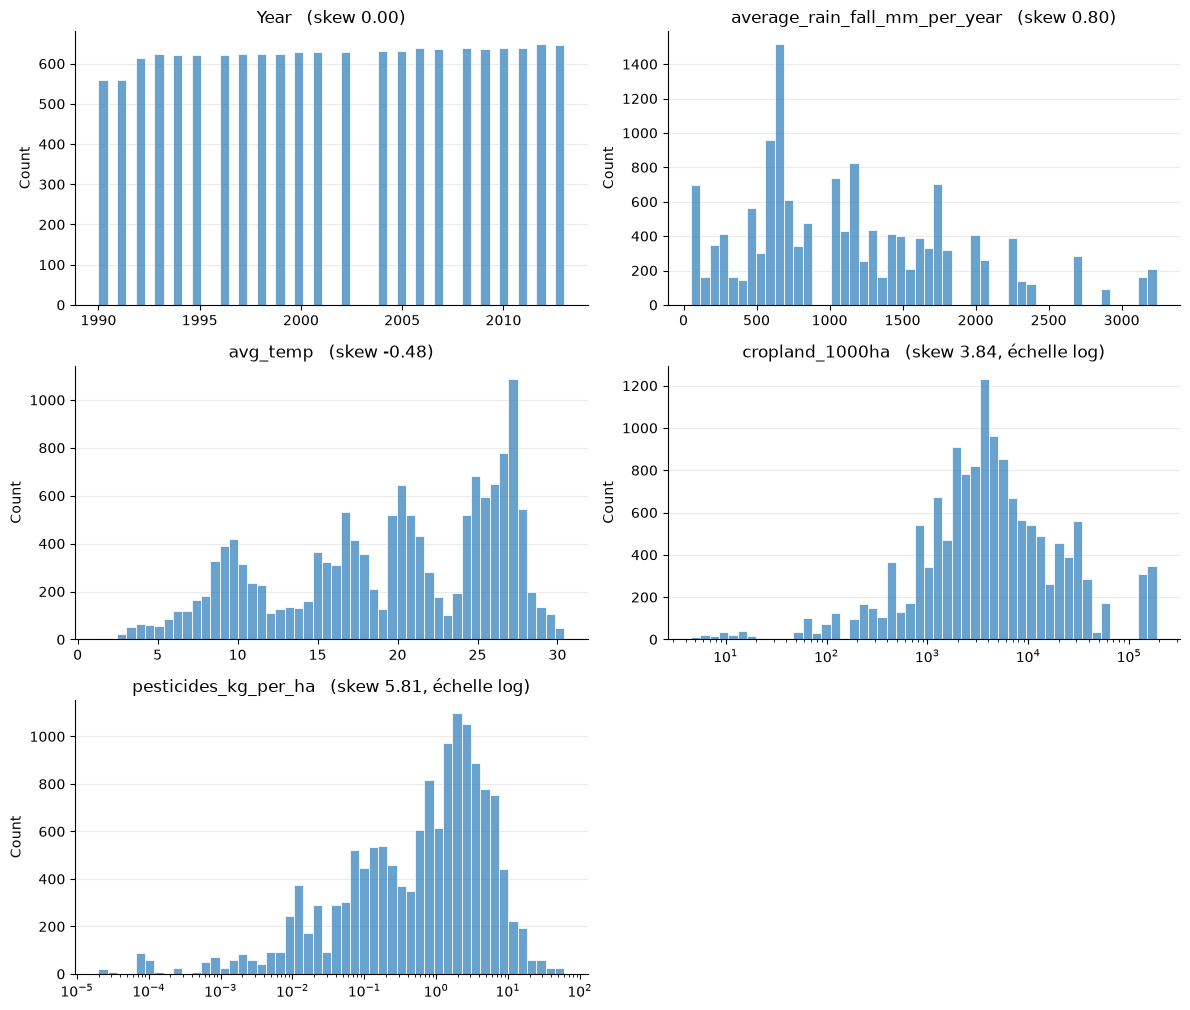

,count,mean,std,min,5%,50%,95%,max
Year,14371.0,2001.62,7.03,1990.00,1991.00,2001.00,2012.00,2013.00
average_rain_fall_mm_per_year,14371.0,1134.34,725.99,51.00,151.00,1032.00,2666.00,3240.00
avg_temp,14371.0,19.47,6.83,1.30,7.67,20.40,27.79,30.42
cropland_1000ha,14371.0,14395.82,32141.09,4.53,236.89,3736.64,60593.00,187776.00
pesticides_kg_per_ha,14371.0,2.46,4.62,0.00,0.01,0.92,8.88,60.57


In [28]:
# One histogram per explanatory variable. Heavily skewed variables get a log x-axis,
# otherwise everything is crushed into the first bin.
n_rows = (len(colnum) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3.4 * n_rows))

for ax, col in zip(axes.flat, colnum):
    skew = B_enriched[col].skew()
    use_log = bool(skew > 2 and B_enriched[col].min() > 0)  # numpy bool would be read as a log base
    sns.histplot(B_enriched[col], bins=50, color=BLUE, alpha=0.7, edgecolor="white",
                 log_scale=use_log, ax=ax)
    ax.set_title(f"{col}   (skew {skew:.2f}{', échelle log' if use_log else ''})")
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

for ax in axes.flat[len(colnum):]:
    ax.set_visible(False)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

display(B_enriched[colnum].describe(percentiles=[0.05, 0.5, 0.95]).T.round(2))

**Des distributions irrégulières, contrairement au dataset A.**

| Variable | Skewness | Lecture |
|---|---|---|
| `Year` | 0,00 | quasi plate : 23 années (2003 manquante), 560 à 648 lignes chacune |
| `avg_temp` | −0,48 | légèrement étalée vers les climats froids, de 1,3 à 30,4 °C |
| `average_rain_fall_mm_per_year` | 0,80 | asymétrique à droite, de 51 à 3 240 mm |
| `cropland_1000ha` | 3,84 | très asymétrique — quelques géants agricoles écrasent tout |
| `pesticides_kg_per_ha` | 5,81 | idem : médiane 0,92 kg/ha, maximum 60,6 |

Les deux dernières sont affichées en **échelle logarithmique**, sinon l'essentiel tombe dans la première
barre. Ces formes reflètent l'inégalité réelle entre pays — dans le dataset A, les trois numériques étaient
des uniformes exactes, signature de la simulation.

## <a id='toc8_2_'></a>[Categorical](#toc0_)

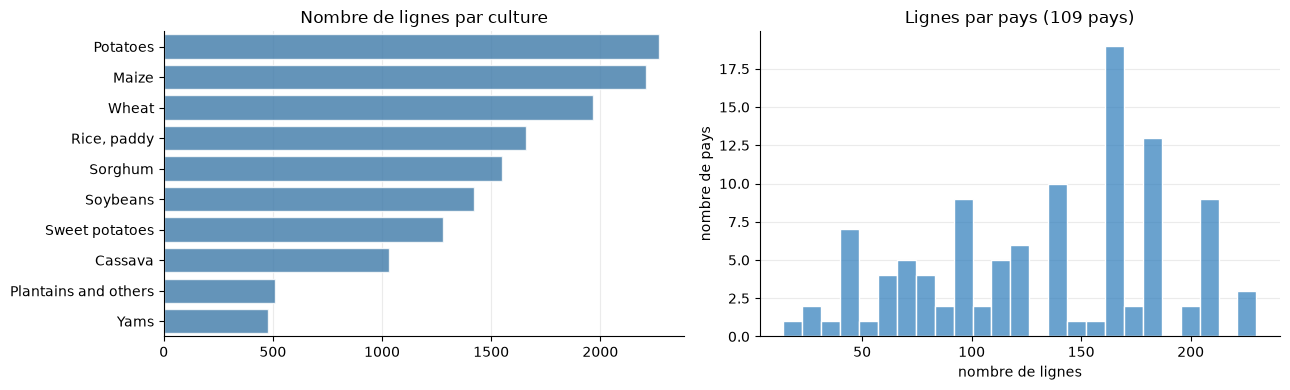

lignes par pays — min 14 | médiane 138 | max 230

une ligne = un couple (culture, année) : 10 cultures x 23 années = 230 au maximum.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Item: 10 modalities, a plain count plot works
order = B_enriched["Item"].value_counts().index
sns.countplot(data=B_enriched, y="Item", order=order, color=BLUE, alpha=0.8,
              edgecolor="white", ax=axes[0])
axes[0].set_title("Nombre de lignes par culture")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)
axes[0].set_axisbelow(True)

# Area: 109 modalities -> plot how many rows each country contributes instead
rows_per_country = B_enriched.groupby("Area").size()
sns.histplot(rows_per_country, bins=25, color=BLUE, alpha=0.7, edgecolor="white", ax=axes[1])
axes[1].set_title(f"Lignes par pays ({len(rows_per_country)} pays)")
axes[1].set_xlabel("nombre de lignes")
axes[1].set_ylabel("nombre de pays")
axes[1].grid(axis="y", alpha=0.25)
axes[1].set_axisbelow(True)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

print(f"lignes par pays — min {rows_per_country.min()} | médiane {rows_per_country.median():.0f} "
      f"| max {rows_per_country.max()}")
print("\nune ligne = un couple (culture, année) : 10 cultures x 23 années = 230 au maximum.")

**Les modalités ne sont pas équilibrées — et c'est normal.**

Côté cultures, les effectifs vont de **477 lignes** (Yams) à **2 270** (Potatoes). Ce n'est pas un défaut
d'échantillonnage, c'est la géographie : Yams ne pousse que dans quelques pays tropicaux, Potatoes
à peu près partout. Côté pays, de **14 à 230 lignes** (médiane 138) pour un maximum de 230 : un pays
à 14 lignes ne cultive qu'une ou deux des dix espèces suivies.

Contraste avec le dataset A : ~166 700 lignes par culture à quelques dizaines près — l'équilibre parfait
d'un tirage aléatoire. Ici, le déséquilibre porte de l'information géographique.

# <a id='toc9_'></a>[Bivariate analysis](#toc0_)

## <a id='toc9_1_'></a>[Numeric vs target](#toc0_)

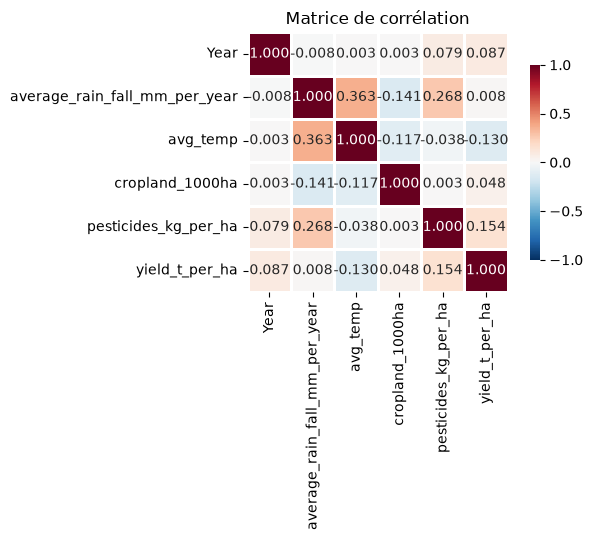

In [30]:
corr = B_enriched[list(colnum) + [target.name]].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=2, linecolor="white", cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Matrice de corrélation")
fig.tight_layout()
plt.show()

**Rien ne dépasse |0,36| — ni entre variables, ni avec la cible.**

Les explicatives sont quasi orthogonales entre elles (maximum : pluie ↔ température, +0,36 — on y reviendra
pour l'ACP). Côté cible, le meilleur Pearson plafonne à +0,15.

**Un `r` global proche de zéro ne signifie pas « variable sans lien avec la cible ».** Il signifie « pas de
relation *linéaire*, mesurée toutes lignes confondues ». Deux mécanismes peuvent l'annuler alors qu'une
relation existe : une relation **non monotone** (une droite ajustée sur une cloche a une pente nulle), et
des relations **de signes opposés selon la culture**, qui se compensent à l'agrégation.

Regardons d'abord la relation directe à la cible, Spearman compris, avant de neutraliser la culture.

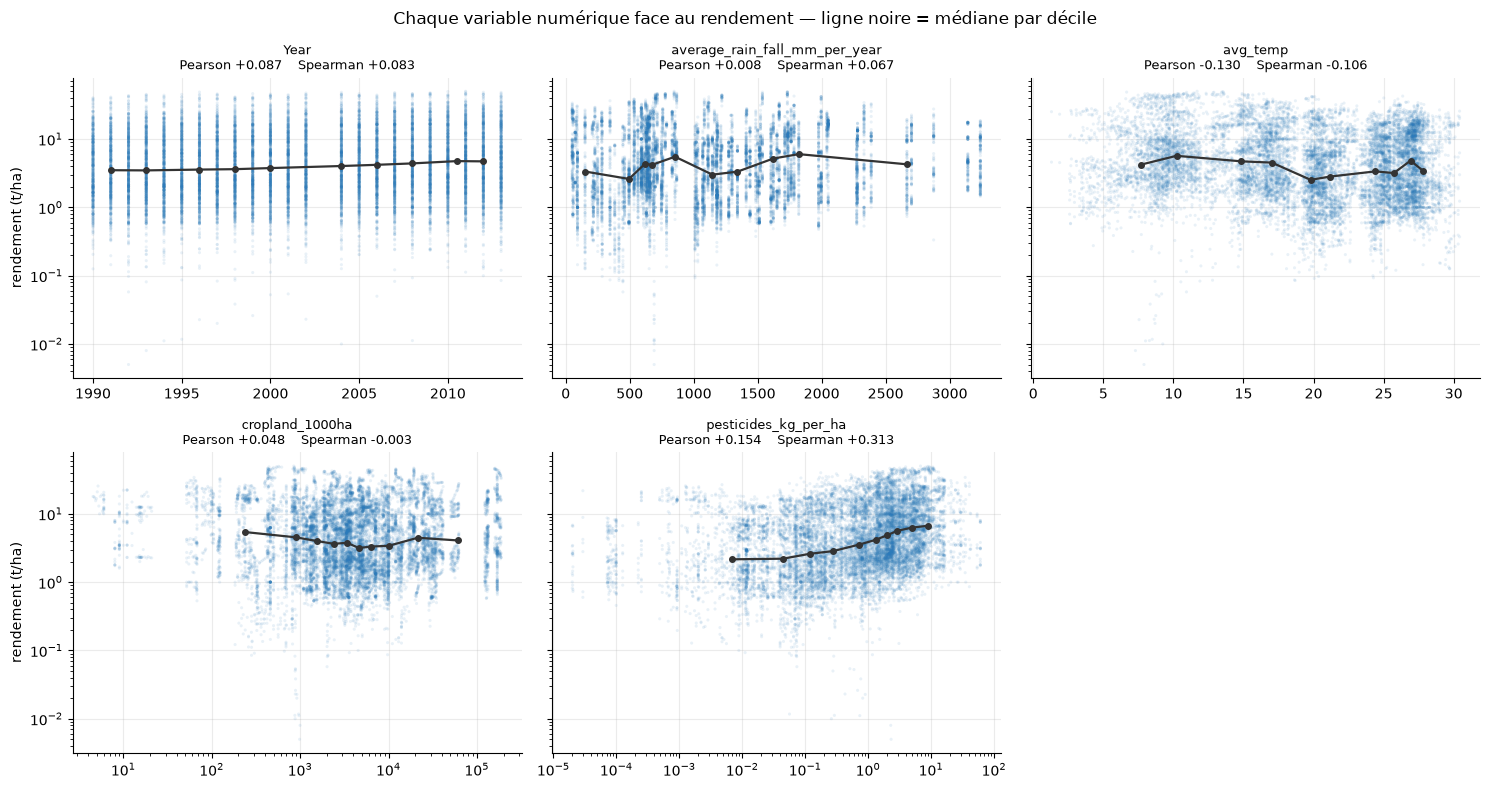

,Pearson,Spearman,écart,skew
pesticides_kg_per_ha,0.154,0.313,0.159,5.811
avg_temp,-0.130,-0.106,0.024,-0.476
Year,0.087,0.083,0.004,0.003
average_rain_fall_mm_per_year,0.008,0.067,0.059,0.801
cropland_1000ha,0.048,-0.003,0.051,3.840


In [31]:
# Each numeric variable against the target. Log scale on heavily skewed axes,
# otherwise the cloud collapses onto the origin.
log_y = bool(B_enriched["yield_t_per_ha"].min() > 0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, col in zip(axes.flat, colnum):
    ax.scatter(B_enriched[col], target, s=5, alpha=0.10, color=BLUE, edgecolors="none")

    # The shape of the link, without the cloud: median yield per decile of the variable.
    dec = pd.qcut(B_enriched[col], 10, labels=False, duplicates="drop")
    med = B_enriched.groupby(dec)[[col, "yield_t_per_ha"]].median()
    ax.plot(med[col], med["yield_t_per_ha"], color=INK, lw=1.6, marker="o", ms=4)

    if bool(B_enriched[col].skew() > 2 and B_enriched[col].min() > 0):
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    r = pearsonr(B_enriched[col], target).statistic
    rho = spearmanr(B_enriched[col], target).statistic
    ax.set_title(f"{col}\nPearson {r:+.3f}    Spearman {rho:+.3f}", fontsize=9)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)

for ax in axes.flat[len(colnum):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("rendement (t/ha)")
fig.suptitle("Chaque variable numérique face au rendement — ligne noire = médiane par décile", fontsize=12)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

rows = {}
for col in colnum:
    r = pearsonr(B_enriched[col], target).statistic
    rho = spearmanr(B_enriched[col], target).statistic
    rows[col] = {"Pearson": r, "Spearman": rho, "écart": abs(rho - r), "skew": B_enriched[col].skew()}
display(pd.DataFrame(rows).T.sort_values("Spearman", key=abs, ascending=False).round(3))

**Aucune variable numérique ne porte de lien fort avec le rendement.**

La plus forte, `pesticides_kg_per_ha`, plafonne à **+0,31** — et seulement en rangs. Deux écarts
Pearson/Spearman méritent lecture :

- `pesticides_kg_per_ha` : +0,15 contre **+0,31**. Lien monotone mais courbé — la variable est très
  asymétrique (skew +5,8) et une poignée de pays intensifs écrase la mesure linéaire, d'où l'axe log.
- `cropland_1000ha` : +0,05 contre −0,00 — pas même d'accord sur le signe ; le +0,05 est tiré par quelques
  très grands pays.

**Surtout, ces chiffres agrègent dix cultures dont les rendements vont de 1 à 12** : mesurés sur
l'ensemble, ils reflètent d'abord la composition en cultures de chaque tranche. La section suivante
neutralise la culture.

## <a id='toc9_2_'></a>[Numeric vs categorical](#toc0_)

Les corrélations ci-dessus sont calculées **toutes cultures confondues**. Or Yams et Wheat n'ont ni
le même climat, ni le même niveau de rendement. Avant de conclure sur une variable numérique, il faut
regarder son comportement **à l'intérieur de chaque culture**.

Première étape : les cultures occupent-elles des niches climatiques différentes ?

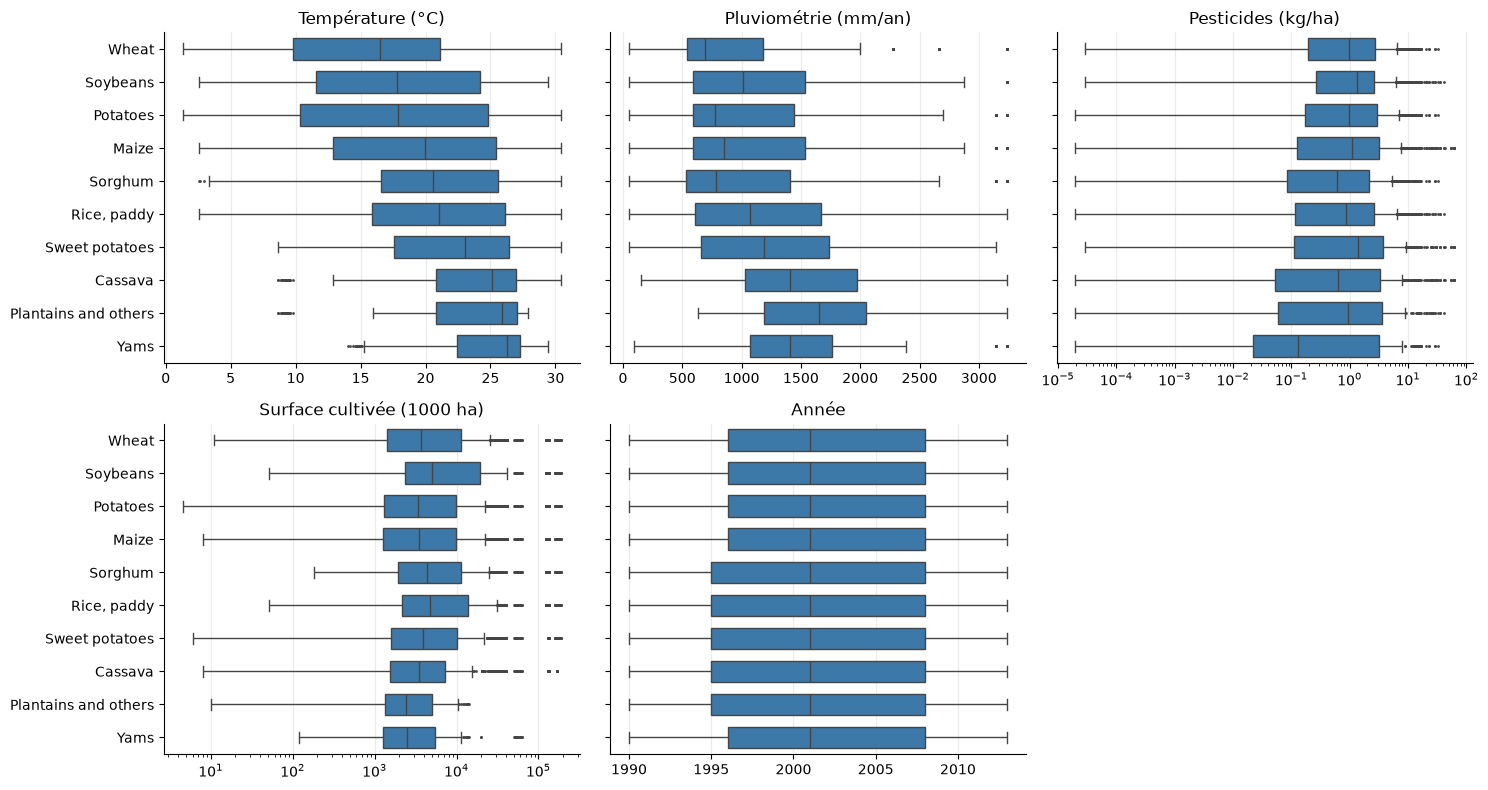

,η² Item (%),η² Area (%)
Year,0.0,0.9
average_rain_fall_mm_per_year,7.6,100.0
avg_temp,12.4,99.6
cropland_1000ha,1.0,99.8
pesticides_kg_per_ha,0.9,79.2


In [32]:
# Each numeric variable, split by crop. Common order: increasing median temperature.
order = B_enriched.groupby("Item")["avg_temp"].median().sort_values().index
labels = {
    "avg_temp": "Température (°C)",
    "average_rain_fall_mm_per_year": "Pluviométrie (mm/an)",
    "pesticides_kg_per_ha": "Pesticides (kg/ha)",
    "cropland_1000ha": "Surface cultivée (1000 ha)",
    "Year": "Année",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, col in zip(axes.flat, labels):
    sns.boxplot(data=B_enriched, x=col, y="Item", order=order, color=BLUE,
                fliersize=1, width=0.65, ax=ax)
    if B_enriched[col].skew() > 2 and B_enriched[col].min() > 0:
        ax.set_xscale("log")
    ax.set_title(labels[col])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

for ax in axes.flat[len(labels):]:
    ax.set_visible(False)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

# How much of each variable's variation do the crop and the country explain?
rows = {}
for col in colnum:
    sct, sce, scr = sums_of_squares(B_enriched[col], B_enriched["Item"])
    rows[col] = {"η² Item (%)": sce / sct * 100}
    sct, sce, scr = sums_of_squares(B_enriched[col], B_enriched["Area"])
    rows[col]["η² Area (%)"] = sce / sct * 100
display(pd.DataFrame(rows).T.round(1))

**Chaque culture occupe sa propre niche climatique.**

Le classement par température est sans surprise agronomique : Wheat, Potatoes et Maize en bas
(climats tempérés), Yams, Cassava et Plantains and others en haut (tropiques). La pluviométrie suit le
même gradient.

C'est exactement le **facteur confondant** qui fausse les corrélations globales : les cultures à fort
rendement (tubercules) sont aussi celles des pays chauds et humides. Une corrélation « pluie ↔ rendement »
calculée sur tout le jeu mesure en réalité « les pays humides cultivent des tubercules », pas « la pluie fait
pousser ».

Il faut donc neutraliser la culture, et recalculer à l'intérieur de chacune.

In [33]:
# Same correlations, but computed inside each crop -> the crop effect can no longer leak in.
NUMERIC = {
    "pluie": "average_rain_fall_mm_per_year",
    "température": "avg_temp",
    "pesticides": "pesticides_kg_per_ha",
}

rows = {}
for crop, g in B_enriched.groupby("Item"):
    rows[crop] = {"n": len(g)} | {
        label: spearmanr(g[col], g["yield_t_per_ha"]).statistic
        for label, col in NUMERIC.items()
    }

within = pd.DataFrame(rows).T.sort_values("pluie")
display(within.round(3))

print("corrélation de Spearman avec le rendement :")
for label, col in NUMERIC.items():
    overall = spearmanr(B_enriched[col], target).statistic
    print(f"   {label:<12} globale {overall:+.3f}   |   intra-culture : "
          f"de {within[label].min():+.3f} à {within[label].max():+.3f} "
          f"(moyenne {within[label].mean():+.3f})")

,n,pluie,température,pesticides
Sweet potatoes,1278.0,-0.168,-0.295,0.359
Potatoes,2270.0,-0.116,-0.357,0.556
Maize,2207.0,-0.108,-0.512,0.555
"Rice, paddy",1661.0,-0.092,-0.321,0.587
Soybeans,1421.0,-0.012,-0.263,0.630
Wheat,1966.0,0.004,-0.424,0.456
Cassava,1033.0,0.166,0.226,0.257
Sorghum,1548.0,0.167,-0.345,0.661
Plantains and others,510.0,0.277,-0.111,0.591
Yams,477.0,0.419,-0.079,0.413


corrélation de Spearman avec le rendement :
   pluie        globale +0.067   |   intra-culture : de -0.168 à +0.419 (moyenne +0.054)
   température  globale -0.106   |   intra-culture : de -0.512 à +0.226 (moyenne -0.248)
   pesticides   globale +0.313   |   intra-culture : de +0.257 à +0.661 (moyenne +0.506)


**Le signe s'inverse selon la culture — d'où la corrélation globale quasi nulle.**

| Culture | pluie ↔ rendement |
|---|---|
| Yams | **+0,419** |
| Plantains and others | +0,277 |
| Sorghum | +0,167 |
| Cassava | +0,166 |
| Wheat | +0,004 |
| Soybeans | −0,012 |
| Rice, paddy | −0,092 |
| Maize | −0,108 |
| Potatoes | −0,116 |
| Sweet potatoes | −0,168 |

Cultures tropicales : plus de pluie va avec plus de rendement ; cultures tempérées : l'inverse. À
l'agrégation ces effets se compensent — le **+0,07** global n'était pas une absence de relation, mais une
moyenne de relations opposées. Même mécanisme sur la température : −0,11 en global, **−0,25** en moyenne
intra-culture, jusqu'à **−0,51** pour Maize.

**Et l'intensité de pesticides ressort largement en tête : +0,31 en global, +0,51 en moyenne
intra-culture, jusqu'à +0,66.** Elle était masquée deux fois — par la non-linéarité, puis par l'agrégation
entre cultures — et n'existait pas avant la normalisation par la surface cultivée.

> **Point de méthode** : sur un jeu stratifié par une catégorielle forte (`Item` porte 53 % de la variance
> de la cible, cf. plus bas), une matrice de corrélation globale n'est pas interprétable : elle mesure
> surtout un effet de composition.

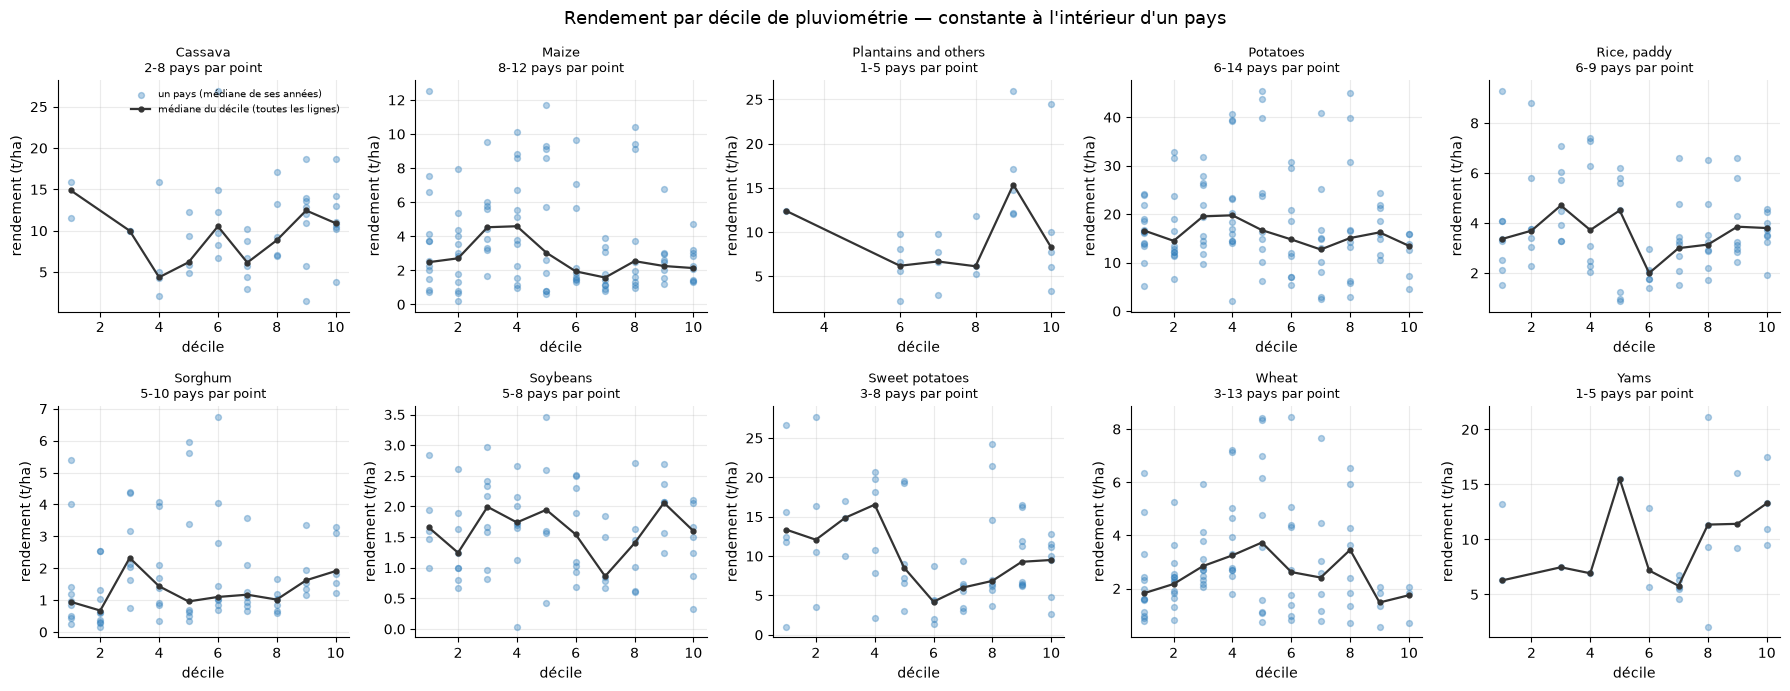

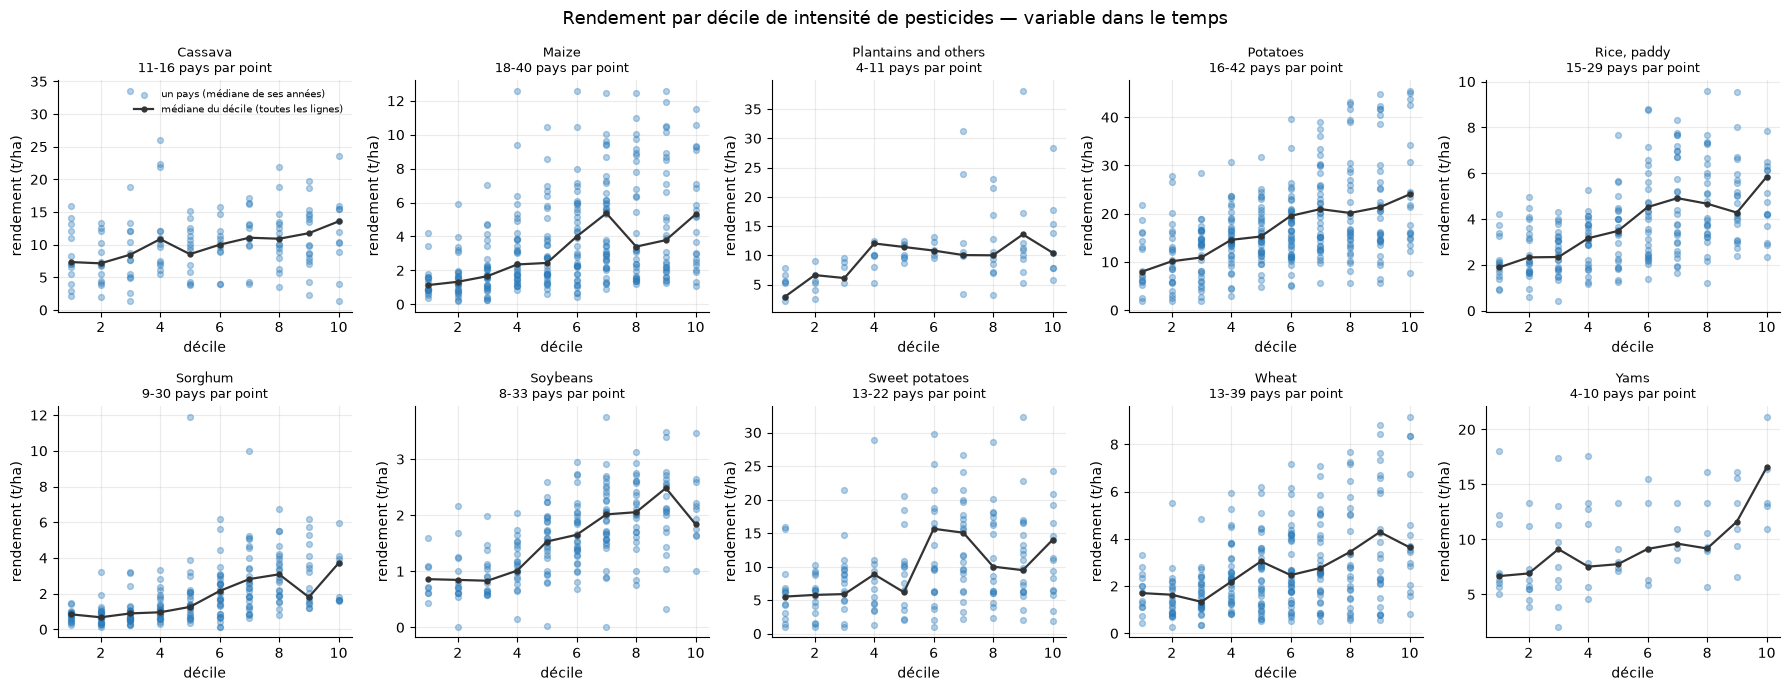

pays dont la pluviométrie ne varie jamais sur 1990-2013 : 109 / 109
   décile 3 — 9 pays : Argentina, Belarus, Bulgaria, Hungary, Kenya, Poland...
      médiane 4.53 t/ha   |   médianes par pays de 1.67 à 9.51
   décile 7 — 9 pays : Albania, Bahamas, Burundi, Central African Republic, Dominican Republic, Haiti...
      médiane 1.58 t/ha   |   médianes par pays de 0.80 à 3.88

déciles de pesticides visités par un même pays : médiane 3, max 7   (figés sur un seul décile : 8/109)

632 couples (pays, culture) suivis au moins dix ans :
   pesticides <-> rendement                     rho médian +0.192   positifs 62 %
   année <-> rendement                          rho médian +0.618   positifs 82 %
   pesticides <-> rendement, à année constante  rho médian +0.026   positifs 53 %


In [34]:
def decile_panels(variable, label):
    """Median yield per decile of a variable, one panel per crop.

    Each country is also plotted individually: when the variable does not vary
    inside a country, a decile is just a group of countries, and the cloud
    shows how fragile the decile median is.
    """
    d = B_enriched.copy()
    d["décile"] = pd.qcut(d[variable], 10, labels=False, duplicates="drop") + 1
    crops = sorted(d["Item"].unique())

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    for ax, crop in zip(axes.flat, crops):
        g = d[d["Item"] == crop]
        per_country = g.groupby(["décile", "Area"])["yield_t_per_ha"].median().reset_index()
        med = g.groupby("décile")["yield_t_per_ha"].median()
        n_countries = g.groupby("décile")["Area"].nunique()

        ax.scatter(per_country["décile"], per_country["yield_t_per_ha"],
                   color=BLUE, alpha=0.35, s=18, zorder=2, label="un pays (médiane de ses années)")
        ax.plot(med.index, med.values, color=INK, lw=1.6, marker="o", ms=3.5, zorder=3,
                label="médiane du décile (toutes les lignes)")
        ax.set_title(f"{crop}\n{n_countries.min()}-{n_countries.max()} pays par point", fontsize=9)
        ax.set_xlabel("décile")
        ax.set_ylabel("rendement (t/ha)")
        ax.grid(alpha=0.25)
        ax.set_axisbelow(True)

    axes.flat[0].legend(frameon=False, fontsize=7)
    fig.suptitle(f"Rendement par décile de {label}", fontsize=13)
    sns.despine(fig=fig)
    fig.tight_layout()
    plt.show()


decile_panels("average_rain_fall_mm_per_year", "pluviométrie — constante à l'intérieur d'un pays")
decile_panels("pesticides_kg_per_ha", "intensité de pesticides — variable dans le temps")

# A rain decile is a group of countries, not a rain level. Proof, on maize:
constant = B_enriched.groupby("Area")["average_rain_fall_mm_per_year"].nunique()
print(f"pays dont la pluviométrie ne varie jamais sur 1990-2013 : {(constant == 1).sum()} / {len(constant)}")

maize = B_enriched[B_enriched["Item"] == "Maize"].copy()
maize["décile"] = pd.qcut(B_enriched["average_rain_fall_mm_per_year"], 10, labels=False,
                          duplicates="drop").reindex(maize.index) + 1
med_by_country = maize.groupby(["décile", "Area"])["yield_t_per_ha"].median()
for d in [3, 7]:
    s = med_by_country.loc[d]
    print(f"   décile {d} — {len(s)} pays : {', '.join(sorted(s.index)[:6])}...")
    print(f"      médiane {maize.loc[maize['décile'] == d, 'yield_t_per_ha'].median():.2f} t/ha"
          f"   |   médianes par pays de {s.min():.2f} à {s.max():.2f}")

# Pesticides do move over time: a country crosses several deciles.
spans = (pd.qcut(B_enriched["pesticides_kg_per_ha"], 10, labels=False, duplicates="drop")
           .groupby(B_enriched["Area"]).nunique())
print(f"\ndéciles de pesticides visités par un même pays : médiane {spans.median():.0f}, "
      f"max {spans.max()}   (figés sur un seul décile : {(spans == 1).sum()}/{len(spans)})")

# Yields rise over time everywhere, and so does pesticide use. To see whether the link
# survives once the year is held constant, compute a partial Spearman correlation inside
# each (country, crop) pair followed for at least ten years.
pest_yield, year_yield, partial = [], [], []
for _, g in B_enriched.groupby(["Area", "Item"]):
    if len(g) < 10 or g["pesticides_kg_per_ha"].nunique() < 5:
        continue
    r_py = spearmanr(g["pesticides_kg_per_ha"], g["yield_t_per_ha"]).statistic
    r_ty = spearmanr(g["Year"], g["yield_t_per_ha"]).statistic
    r_pt = spearmanr(g["pesticides_kg_per_ha"], g["Year"]).statistic
    if np.isnan([r_py, r_ty, r_pt]).any():
        continue
    pest_yield.append(r_py)
    year_yield.append(r_ty)
    denominator = np.sqrt((1 - r_pt ** 2) * (1 - r_ty ** 2))
    if denominator > 1e-9:
        partial.append((r_py - r_pt * r_ty) / denominator)

print(f"\n{len(pest_yield)} couples (pays, culture) suivis au moins dix ans :")
for name, values in [("pesticides <-> rendement", pest_yield),
                     ("année <-> rendement", year_yield),
                     ("pesticides <-> rendement, à année constante", partial)]:
    values = np.array(values)
    print(f"   {name:<44} rho médian {np.median(values):+.3f}"
          f"   positifs {100 * (values > 0).mean():.0f} %")

**PLUVIOMETRIE : Les courbes n'ont pas de forme lisible**

Wheat a un second pic au décile 8, Rice, paddy plonge au 6 puis remonte, Cassava s'effondre au 4. La raison
est visible dans le nuage : chaque point ne repose que sur **1 à 14 pays**, et la pluviométrie est
**constante pour les 109 pays**. Un décile n'est donc pas un « niveau de pluie », c'est **un groupe de
pays**. Pour Maize :

```
décile 3  ->  9 pays (Argentine, Biélorussie, Bulgarie...)   médiane 4,53 t/ha   par pays : de 1,67 à 9,51
décile 7  ->  9 pays (Albanie, Bahamas, Burundi...)          médiane 1,58 t/ha   par pays : de 0,80 à 3,88
```

Les fourchettes par pays se recouvrent largement : l'écart entre ces deux points ne mesure pas un effet de
la pluie, il sépare la ceinture céréalière européenne d'un groupe de pays peu mécanisés. **La courbe classe
des pays par développement agricole, dans un ordre qui se trouve être celui de la pluviométrie.**

> **Conclusion sur `average_rain_fall_mm_per_year`.** Ces données ne permettent pas d'estimer une réponse
> du rendement à la pluviométrie : la variable **ne varie jamais à l'intérieur d'un pays** (0 % de variance
> intra-pays), il n'existe aucune variation exploitable. Toute courbe tracée est une comparaison entre
> pays, confondue avec tout ce qui les distingue — richesse, mécanisation, sols, latitude. Les corrélations
> intra-culture ci-dessus se lisent donc « parmi les pays qui cultivent de Yams, les plus humides ont
> de meilleurs rendements » : un constat entre pays, pas un effet de la pluie.

**USAGE DE PESTICIDE**

Contrairement à la pluie, l'intensité de pesticides bouge à l'intérieur d'un pays : 21 % de variance
intra-pays, un pays traverse **3 déciles en médiane** (jusqu'à 7), seuls 8 sur 109 restent figés. Les dix
courbes montent — reste à savoir ce qui les fait monter. À l'intérieur de chaque couple *(pays, culture)*
suivi au moins dix ans :

| Corrélation intra (pays × culture) | ρ médian | positifs |
|---|---|---|
| pesticides ↔ rendement | +0,19 | 62 % |
| **année ↔ rendement** | **+0,62** | **82 %** |
| pesticides ↔ rendement, **à année constante** | **+0,03** | **53 %** |

Le rendement progresse dans le temps dans 82 % des séries — semences, mécanisation, pratiques. L'usage de
pesticides progresse aussi. Les deux montent ensemble, mais chacun de son côté : à année constante il reste
**+0,03**, positif dans 53 % des cas — un pile ou face. Le lien net est **entre pays** (ρ intra-culture de
+0,26 à +0,66, cohérent avec l'η² pays de 79 %).

> **Ce que montre la figure** : un classement des pays par niveau d'intensification agricole, doublé d'une
> tendance temporelle — pas une courbe dose–réponse. Les données ne contiennent pas de quoi dire ce que
> devient un rendement quand un pays change ses pratiques.

## <a id='toc9_3_'></a>[Categorical vs target — là où est le signal](#toc0_)

C'est le test qui justifie tout le projet. Dans le dataset A, la culture faisait varier le rendement moyen
de **0,012 t/ha** — du bruit d'arrondi, ce qui rendait la recommandation impossible. Même mesure ici.

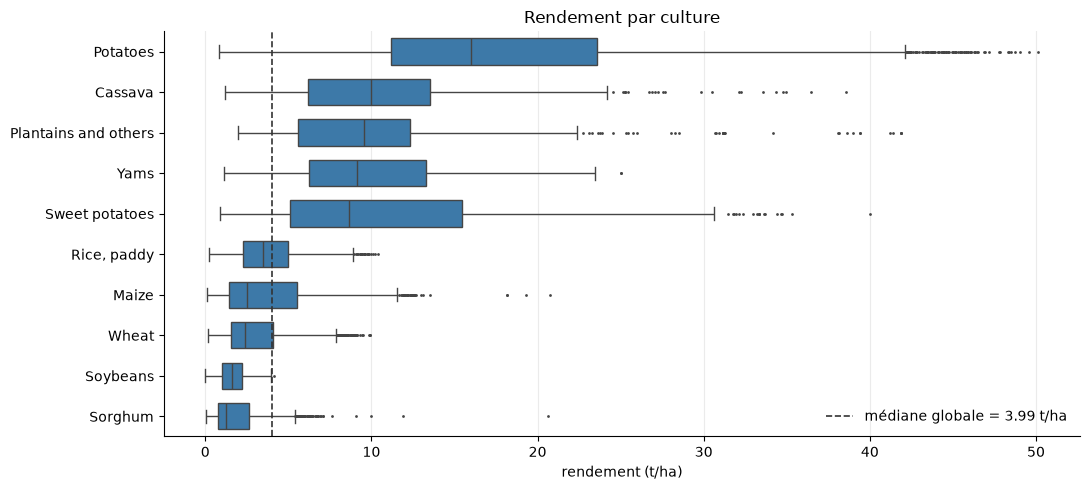

,modalités,SCE / SCT (%),écart entre moyennes (t/ha)
Item,10.0,53.23,16.51
Area,109.0,20.57,23.36
Year,23.0,0.77,2.13


In [35]:
order = B_enriched.groupby("Item")["yield_t_per_ha"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=B_enriched, x="yield_t_per_ha", y="Item", order=order,
            color=BLUE, fliersize=1, width=0.65, ax=ax)
ax.axvline(target.median(), color=INK, ls="--", lw=1.2,
           label=f"médiane globale = {target.median():.2f} t/ha")
ax.set_title("Rendement par culture")
ax.set_xlabel("rendement (t/ha)")
ax.set_ylabel("")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

# How much of the yield variation does each factor explain?
rows = {}
for cat in ["Item", "Area", "Year"]:
    sct, sce, scr = sums_of_squares(B_enriched["yield_t_per_ha"], B_enriched[cat])
    means = B_enriched.groupby(cat)["yield_t_per_ha"].mean()
    rows[cat] = {
        "modalités": B_enriched[cat].nunique(),
        "SCE / SCT (%)": sce / sct * 100,
        "écart entre moyennes (t/ha)": means.max() - means.min(),
    }
display(pd.DataFrame(rows).T.round(2))

**Le signal est porté par la culture.**

| Facteur | Modalités | **η² = SCE / SCT** | Écart entre moyennes |
|---|---|---|---|
| **`Item`** | 10 | **53,2 %** | 16,51 t/ha |
| `Area` | 109 | 20,6 % | 23,36 t/ha |
| `Year` | 23 | 0,8 % | 2,13 t/ha |

**La culture explique 53 % de la variation du rendement.** C'est exactement ce que le dataset A n'avait
pas : le même calcul y donnait **η² = 0,0006 %** pour `Crop`, un facteur ~90 000. Le classement se lit sur
le graphe : tubercules en haut (Potatoes, 16 t/ha médians), céréales et Soybeans en bas (Sorghum, 1,26) —
un rapport de 1 à 12.

> **Attention à la dernière colonne — elle induit en erreur.** L'écart entre moyennes extrêmes donne `Area`
> gagnant (23,36 t/ha) : artefact, car il ne compare que deux modalités en ignorant les effectifs, et avec
> 109 pays on trouve toujours un extrême. Le η² pondère toutes les modalités par leurs effectifs et tranche
> dans l'autre sens : **`Item` 53,2 % contre `Area` 20,6 %**. η² étant lui-même mécaniquement gonflé par un
> grand nombre de modalités, les 20,6 % de `Area` (109 modalités contre 10) sont plutôt surestimés — la
> domination de la culture est robuste.

## <a id='toc9_4_'></a>[Redondance et ACP](#toc0_)

Le brief demande une **analyse en composantes principales « pour identifier les variables clés »**.

Avant de la lancer, une question soulevée par l'analyse précédente : `Area` pèse sur la cible (η² = 20,6 %). Or la pluviométrie est constante par pays. **Peut-on retrouver
le pays à partir du climat ?**

In [36]:
# Can a climate value be traced back to a single country?
print(f"pays dans le jeu de données : {B_enriched['Area'].nunique()}")
for col in ["average_rain_fall_mm_per_year", "avg_temp", "pesticides_kg_per_ha"]:
    print(f"   {col:<32} {B_enriched[col].nunique():>5} valeurs distinctes")

rain_to_country = B_enriched.groupby("average_rain_fall_mm_per_year")["Area"].nunique()
print(f"\nvaleurs de pluie partagées par plusieurs pays : {(rain_to_country > 1).sum()} / {len(rain_to_country)}"
      f"   -> identification unique dans {(rain_to_country == 1).mean() * 100:.0f} % des cas")

pair_to_country = B_enriched.groupby(["average_rain_fall_mm_per_year", "avg_temp"])["Area"].nunique()
print(f"couples (pluie, température) ambigus        : {(pair_to_country > 1).sum()} / {len(pair_to_country)}")

pays dans le jeu de données : 109
   average_rain_fall_mm_per_year      108 valeurs distinctes
   avg_temp                          1714 valeurs distinctes
   pesticides_kg_per_ha              2333 valeurs distinctes

valeurs de pluie partagées par plusieurs pays : 1 / 108   -> identification unique dans 99 % des cas
couples (pluie, température) ambigus        : 0 / 2287


**Le climat est un identifiant de pays.**

109 pays, **108 valeurs distinctes de pluviométrie** : une seule valeur est partagée par deux pays. Et le
couple (pluie, température) ne présente **aucune ambiguïté** — 0 cas sur 2 287.

`average_rain_fall_mm_per_year` n'est pas une variable climatique au sens usuel : c'est **un identifiant de
pays exprimé sous forme numérique**.

`Area` et le bloc climatique portent donc la même information. Une ACP peut-elle en tirer parti ?

variance expliquée : [0.2984 0.2212 0.1937 0.1818 0.1048]
cumulée            : [0.2984 0.5197 0.7134 0.8952 1.    ]


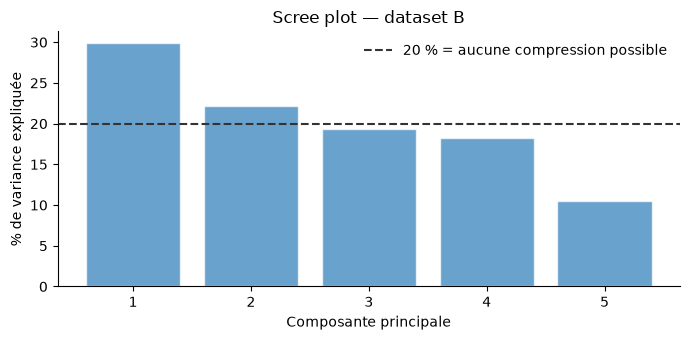

In [37]:
# Correlations between the features were shown in the heatmap above (max 0.36):
# that is all PCA has to work with.
pca = PCA().fit(StandardScaler().fit_transform(B_enriched[colnum]))
ratios = pca.explained_variance_ratio_
print("variance expliquée :", ratios.round(4))
print("cumulée            :", ratios.cumsum().round(4))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(1, len(ratios) + 1), ratios * 100, color=BLUE, alpha=0.7, edgecolor="white")
ax.axhline(100 / len(ratios), color=INK, ls="--", lw=1.5,
           label=f"{100 / len(ratios):.0f} % = aucune compression possible")
ax.set_xticks(range(1, len(ratios) + 1))
ax.set_xlabel("Composante principale")
ax.set_ylabel("% de variance expliquée")
ax.set_title("Scree plot — dataset B")
ax.legend(frameon=False)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**L'ACP ne compresse rien — et c'est le résultat intéressant.**

| | Composantes |
|---|---|
| **Dataset A** (3 variables) | 0,334 · 0,333 · 0,332 |
| **Dataset B** (5 variables) | 0,298 · 0,221 · 0,194 · 0,182 · 0,105 |

Chaque composante pèse entre 10 et 30 % ; les 4 premières n'atteignent que **89,5 %** de la variance. Rien
à supprimer.

**Pourquoi l'ACP ne voit-elle rien alors que le climat identifie le pays ?** Parce que ce sont deux notions
différentes. L'ACP ne répond qu'à une question : ces colonnes *montent-elles et descendent-elles
ensemble* ? Ici non (corrélation max +0,36) : pluie et température sont chacune constante par pays, mais un
pays peut être chaud-sec, chaud-humide, froid-sec ou froid-humide — **deux axes indépendants** qui,
combinés, désignent une case unique. La redondance n'est pas *entre* les variables numériques : elle est
entre le **bloc numérique et `Area`**, une catégorielle que l'ACP ne regarde pas.

> **Réponse à la demande du brief** — « une ACP est attendue pour identifier les variables clés » : ici,
> elle ne les identifie pas. Elle établit qu'il n'existe pas de redondance linéaire exploitable entre les
> colonnes numériques. Les variables clés ressortent autrement : corrélations intra-culture
> (`pesticides_kg_per_ha` +0,51) et η² (`Item` **53,2 %**, `Area` 20,6 %). **Le signal est catégoriel, pas
> numérique** — aucune méthode linéaire appliquée aux colonnes numériques ne pouvait le trouver.

Les deux scree plots (A et B) sont plats pour des raisons opposées : variables tirées indépendamment dans
A, facettes différentes d'un même pays dans B.

# <a id='toc10_'></a>[Conclusions de l'EDA](#toc0_)

## <a id='toc10_1_'></a>[La cible](#toc0_)

Rendement à queue droite épaisse : médiane 3,99 t/ha, moyenne 7,05, skewness 2,11 — quasi symétrique en log
(−0,20). L'échelle log est l'échelle naturelle de la variable.

**Les 917 « outliers » de la règle 1,5 × IQR sont tous des tubercules**, aucune céréale : mélange de
populations, pas anomalies — la même règle appliquée par culture n'en garde que 370. **Aucune suppression.**

## <a id='toc10_2_'></a>[Les variables explicatives](#toc0_)

| Constat | Détail |
|---|---|
| Aucune corrélation **linéaire globale** ne dépasse 0,15 | et une corrélation globale n'est pas interprétable ici : `Item` porte 53 % de la variance de la cible |
| Intra-culture, le signe de la pluie **s'inverse** | +0,42 (Yams) à −0,17 (Sweet potatoes) : le +0,07 global était une moyenne de relations opposées |
| **Aucune réponse à la pluviométrie n'est estimable** | la variable ne varie jamais dans un pays (109/109) ; un décile de pluie est un groupe de pays |
| Température : −0,11 en global, **−0,25 intra-culture**, jusqu'à −0,51 (Maize) | masquée par l'agrégation |
| **`pesticides_kg_per_ha` : +0,31 global, +0,51 intra-culture, jusqu'à +0,66** | la numérique la plus liée à la cible — née de la normalisation par la surface cultivée |
| Mais ce lien est **entre pays**, pas dans le temps | à (pays, culture) fixés et **à année constante**, il tombe à **+0,03** : c'est la progression générale des rendements qui porte la corrélation |
| **`Item` explique 53,2 % de la variation du rendement** (η²) | c'est là qu'est le signal — contre 0,0006 % pour `Crop` dans le dataset A |
| `Area` : 20,6 % ; `Year` : 0,8 % | le pays compte deux fois et demie moins que la culture ; l'année presque pas |

## <a id='toc10_3_'></a>[L'ACP demandée par le brief](#toc0_)

Aucune compression : les 4 premières composantes sur 5 n'atteignent que 89,5 % de la variance, corrélations
inter-variables ≤ 0,36. Elle n'identifie pas les variables clés — elle établit qu'il n'y a pas de redondance
linéaire à exploiter entre les colonnes numériques. Le résultat utile est ailleurs : **le couple (pluie,
température) identifie le pays sans aucune ambiguïté** (0 cas sur 2 287) — `average_rain_fall_mm_per_year`
est un identifiant de pays exprimé sous forme numérique.

## <a id='toc10_4_'></a>[Synthèse](#toc0_)

Le signal de ce jeu de données est **catégoriel** : 16,5 t/ha d'écart entre cultures (210 % de l'écart-type
de la cible), rapport de 1 à 12 entre Sorghum et Potatoes. Les variables numériques n'apportent
qu'un signal faible, largement confondu avec l'identité du pays — à l'exception de l'intensité de
pesticides, seule à varier réellement dans le temps à l'intérieur d'un pays. Et l'espace (culture × climat)
n'est pas couvert uniformément : en contexte tempéré, 3 cultures sur 10 n'ont aucune observation.

In [38]:
B_enriched.to_csv("df.csv", index_label=False)
